# 05 — Sentiment and Topic Analysis

**Research sub-questions answered in this notebook**

1. What is the emotional tone of the Hormuz / jet-fuel discourse on Reddit and YouTube,
   and how robust is that tone across three different scoring methods?
2. What recurring themes or frames organise the discussion, and how do those themes
   distribute across the two platforms?
3. Which topics carry the most negative or uncertain sentiment by platform?
4. Are the topic structure and sentiment patterns stable enough to defend in the report?

**Inputs.** The stable preprocessed comment tables produced by Notebooks 1 and 2:
`data/processed/01_preprocessed/youtube_comments.csv` (or `.parquet`) and
`reddit_comments.csv` (or `.parquet`). The dual cleaning columns (`clean_text` for
topics / lexicons, `vader_text` for sentiment) and the lemma stream (`tokens`,
`lemma_text`) are used as designed in Notebooks 1 and 2.

**Outputs.** Persisted artefacts under `data/processed/03_sentiment_topics/` and
`plots/`. Every claim in the final-cell findings can be traced back to a CSV in
that folder.

## Course-pillar mapping

| Component | Course week | Status |
|---|---|---|
| Opinion-word counting (Bing Liu lexicon) | W4 | Course-aligned baseline |
| VADER (rule-based, social-media-tuned) | W4 | Course-aligned sentiment baseline |
| CardiffNLP `twitter-roberta-base-sentiment-latest` | extension | Headline sentiment scorer |
| LDA topic modelling on count vectors | W6 | Course-aligned headline topic model |
| Manual topic labels and per-topic interpretation | W6 | Course-aligned analytical step |
| Topic diagnostics and stability checks | extension | HD-tier validation additions |
| Topic stability across random seeds | extension | HD-tier robustness check |

**Design decision: dual cleaning.** VADER and the transformer both score on
`vader_text` (capitalisation, punctuation, and emoji cues preserved by NB1/NB2).
The lexicon baseline scores on `tokens` (lower-cased, stop-worded, lemmatised) so
it is directly comparable to the W4 workshop pipeline. Topic models score on
`clean_text` / `lemma_text` as appropriate for each vectoriser.

## Pipeline overview

The notebook is intentionally staged so every analytic step can be inspected
independently before the next step depends on it.

1. **Setup + load + schema check.**
2. **Sentiment — Bing Liu opinion-word counting (W4 baseline).**
3. **Sentiment — VADER (W4 course baseline).**
4. **Sentiment — transformer headline scorer (extension).**
5. **Three-method comparison.** Side-by-side bars, pairwise agreement %, 3 confusion
   matrices, direction-split disagreement samples, Cohen's κ.
6. **Sentiment over time.** Per-platform daily mean compound + 7-day rolling + volume overlay.
7. **Sentiment by subreddit and channel.**
8. **Topic modelling — choosing k.** LDA perplexity sweep + optional NMF comparison.
9. **Topic modelling — LDA at chosen k (W6).** Top-15 words per topic + per-topic bars.
10. **Manual topic labels and representative comments.**
11. **Reddit vs YouTube LDA alignment.** Top-term Jaccard between platform-specific topics.
13. **Topic prevalence by platform, subreddit, and channel.**
14. **Transformer sentiment composition by topic — which topics carry the negative tone.**
15. **Topic quality diagnostics + stability check (3 random seeds).**
16. **Findings and headline numbers for the report.**


## Setup


In [1]:
"""Setup — paths, imports, display settings, version log."""

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA = PROJECT_ROOT / "data"
PROCESSED = DATA / "processed"
RAW = DATA / "raw"
EXTERNAL = PROCESSED / "00_external"
PREPROCESSED = PROCESSED / "01_preprocessed"
FEATURES = PROCESSED / "02_features"
SENTIMENT_TOPICS = PROCESSED / "03_sentiment_topics"
NETWORKS = PROCESSED / "04_networks"
DIFFUSION = PROCESSED / "05_diffusion"
COMPARISON = PROCESSED / "06_comparison"
for d in (EXTERNAL, PREPROCESSED, FEATURES, SENTIMENT_TOPICS, NETWORKS, DIFFUSION, COMPARISON):
    d.mkdir(parents=True, exist_ok=True)
PLOTS = PROJECT_ROOT / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
LEXICONS = PROJECT_ROOT / "lexicons"
OPINION_LEXICON_DIR = LEXICONS / "opinion_lexicon"

import itertools
import json
import re
import warnings
from collections import Counter
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

# Reproducibility log — useful when re-running months later.
import sklearn
print("Versions in use:")
print(f"  python  : {sys.version.split()[0]}")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  sklearn : {sklearn.__version__}")
try:
    import transformers, torch
    print(f"  transformers : {transformers.__version__}")
    print(f"  torch        : {torch.__version__}")
except Exception as exc:
    print(f"  transformers : not available ({type(exc).__name__})")


Versions in use:
  python  : 3.12.10
  pandas  : 3.0.3
  numpy   : 2.4.5
  sklearn : 1.8.0


/Users/emilija/Documents/###master/RMIT/nlp/assignment_2/smna-assignment-02-hormuz-jetfuel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  transformers : 5.8.1
  torch        : 2.12.0


## 1 · Load the preprocessed corpus and run a schema check

Before any modelling we load the Reddit + YouTube preprocessed comment tables and
explicitly verify that every column we rely on downstream is present. If a later
result changes, the reader can see whether the input corpus changed first.

Required columns: `platform, comment_id, clean_text, vader_text, lemma_text, tokens, language, date, author_hash`.
VADER and the transformer consume `vader_text`, the lexicon baseline consumes the `tokens` field, and
the topic models consume `lemma_text`. The transformer becomes the headline sentiment source when labels are available.


In [2]:
def load_comments(preprocessed_dir):
    """Load Reddit + YouTube preprocessed comments from CSV files only."""
    frames = []
    missing_files = []

    for stem in ("youtube_comments", "reddit_comments"):
        path = preprocessed_dir / f"{stem}.csv"
        if path.exists():
            frames.append(pd.read_csv(path))
        else:
            missing_files.append(path)

    if not frames:
        expected = "\n  - ".join(str(p) for p in missing_files)
        raise FileNotFoundError(
            f"No preprocessed CSV comment files found under {preprocessed_dir}.\n"
            f"Expected:\n  - {expected}"
        )

    df = pd.concat(frames, ignore_index=True, sort=False)
    if "language" in df.columns:
        df = df[df["language"] == "en"].copy()
    return df.reset_index(drop=True)


df = load_comments(PREPROCESSED)

REQUIRED_COLUMNS = {
    "platform", "comment_id", "clean_text", "vader_text",
    "lemma_text", "tokens", "language", "date", "author_hash",
}
missing = sorted(REQUIRED_COLUMNS - set(df.columns))
assert not missing, f"Missing required columns: {missing}"

# Coverage check on vader_text (used by VADER + transformer).
vader_coverage = (df["vader_text"].fillna("").str.len() > 0).mean()
print(f"Loaded {len(df):,} English comments.")
print(f"vader_text non-empty coverage: {vader_coverage * 100:.1f}%")
assert vader_coverage > 0.95, "vader_text coverage <95% — check preprocessing in NB1/NB2."

corpus_summary = (
    df.groupby("platform")
      .agg(
          comments=("comment_id", "size"),
          unique_authors=("author_hash", "nunique"),
          unique_dates=("date", "nunique"),
          mean_char_count=("clean_text", lambda s: s.fillna("").str.len().mean()),
          empty_lemma_share=("lemma_text", lambda s: s.fillna("").str.len().eq(0).mean()),
      )
      .reset_index()
)
print("\nPer-platform corpus summary:")
display(corpus_summary)


Loaded 43,298 English comments.
vader_text non-empty coverage: 100.0%

Per-platform corpus summary:


,platform,comments,unique_authors,unique_dates,mean_char_count,empty_lemma_share
0,reddit,17162,10795,75,166.903566,0.0
1,youtube,26136,19676,76,128.734198,0.0


## 2 · Sentiment — Bing Liu opinion-word counting (Week 4 baseline)

The simplest sentiment-analysis approach from Week 4: count positive minus negative
tokens in each comment using the Hu & Liu / Bing Liu opinion lexicon
(`lexicons/opinion_lexicon/positive.txt` and `negative.txt`).

$$\textsf{sentiment} = \#\textsf{positive tokens} - \#\textsf{negative tokens}$$

- score > 0 → positive
- score = 0 → neutral
- score < 0 → negative

**Limitations to keep in mind.** This method ignores negation, intensifiers,
sarcasm, punctuation, sentence-level context, and the geopolitical / market register
of this corpus. The lexicon was originally derived from product reviews, so terms
specific to Hormuz / oil-market discourse (`sanction`, `embargo`, `crude`, `pump`,
`bearish`, `bullish`, `pump-and-dump`) carry no signal here. We keep it explicitly
as the transparent course-aligned baseline against which the more sophisticated
scorers (VADER, transformer) can be compared.


In [3]:
def load_opinion_lexicon(opinion_dir):
    """Load Bing Liu positive + negative word lists.

    The classic distribution of the negative file is Latin-1; the positive
    file is plain ASCII. Both can have ';'-prefixed header comments. We
    decode both robustly, lowercase, and drop comments.
    """
    out = {}
    for name, fname in (("positive", "positive.txt"), ("negative", "negative.txt")):
        path = opinion_dir / fname
        if not path.exists():
            raise FileNotFoundError(f"Missing opinion lexicon file: {path}")
        for enc in ("utf-8", "latin-1"):
            try:
                lines = path.read_text(encoding=enc).splitlines()
                break
            except UnicodeDecodeError:
                continue
        words = {
            ln.strip().lower()
            for ln in lines
            if ln.strip() and not ln.startswith(";")
        }
        out[name] = words
    return out


opinion_lex = load_opinion_lexicon(OPINION_LEXICON_DIR)
print(f"Bing Liu opinion lexicon loaded:")
print(f"  positive words: {len(opinion_lex['positive']):,}")
print(f"  negative words: {len(opinion_lex['negative']):,}")
overlap = opinion_lex["positive"] & opinion_lex["negative"]
print(f"  positive/negative overlap: {len(overlap)} (will be treated as ambiguous and ignored if non-trivial)")
print(f"\nSample positives: {sorted(opinion_lex['positive'])[:8]}")
print(f"Sample negatives: {sorted(opinion_lex['negative'])[:8]}")


Bing Liu opinion lexicon loaded:
  positive words: 2,007
  negative words: 4,783
  positive/negative overlap: 3 (will be treated as ambiguous and ignored if non-trivial)

Sample positives: ['a+', 'abound', 'abounds', 'abundance', 'abundant', 'accessable', 'accessible', 'acclaim']
Sample negatives: ['2-faced', '2-faces', 'abnormal', 'abolish', 'abominable', 'abominably', 'abominate', 'abomination']


In [4]:
def _tokens_from_value(value):
    """Accept either a list (parquet preserves) or a space-joined string (CSV)."""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, str):
        return value.split()
    return []


def score_lexicon_count(df, pos_words, neg_words, token_col="tokens"):
    """Count positive minus negative tokens per comment (Week-4 baseline)."""
    if token_col not in df.columns:
        raise KeyError(f"Token column {token_col!r} not in DataFrame")
    pos_words = set(pos_words)
    neg_words = set(neg_words)
    # Tokens that appear in both lists are dropped — they're ambiguous polarity-carriers
    # and the simple count formula has no way to distinguish them.
    ambiguous = pos_words & neg_words
    if ambiguous:
        pos_words = pos_words - ambiguous
        neg_words = neg_words - ambiguous

    rows = []
    for toks in df[token_col].map(_tokens_from_value):
        toks_lower = [t.lower() for t in toks]
        n_pos = sum(1 for t in toks_lower if t in pos_words)
        n_neg = sum(1 for t in toks_lower if t in neg_words)
        score = n_pos - n_neg
        label = "positive" if score > 0 else ("negative" if score < 0 else "neutral")
        rows.append((score, n_pos, n_neg, label))

    out = df.copy()
    out[["lex_score", "lex_pos_count", "lex_neg_count", "lex_label"]] = pd.DataFrame(
        rows, index=out.index
    )
    return out


df = score_lexicon_count(df, opinion_lex["positive"], opinion_lex["negative"])

print("Bing Liu opinion-word baseline — sentiment distribution per platform:\n")
lex_dist = (df.groupby("platform")["lex_label"]
              .value_counts(normalize=True).unstack(fill_value=0) * 100)
lex_dist = lex_dist.reindex(columns=["negative", "neutral", "positive"], fill_value=0).round(1)
display(lex_dist)
print("\nAggregate score statistics per platform:")
display(df.groupby("platform")["lex_score"].describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

print("\nSample comments (lexicon-baseline labels):")
for label in ("positive", "negative", "neutral"):
    print(f"\n  --- {label.upper()} examples ---")
    sample = df[df["lex_label"] == label].sample(min(3, (df["lex_label"] == label).sum()), random_state=11)
    for _, row in sample.iterrows():
        print(f"    [{row['platform']:7s}  score={row['lex_score']:+d}  pos={row['lex_pos_count']} neg={row['lex_neg_count']}]")
        print(f"     {(row['clean_text'] or '')[:160]!r}")


Bing Liu opinion-word baseline — sentiment distribution per platform:



lex_label,negative,neutral,positive
platform,,,
reddit,34.9,42.1,23.0
youtube,33.0,44.3,22.8



Aggregate score statistics per platform:


,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
reddit,17162.0,-0.307074,1.673824,-25.0,-1.0,0.0,0.0,12.0
youtube,26136.0,-0.261172,1.695460,-65.0,-1.0,0.0,0.0,14.0



Sample comments (lexicon-baseline labels):

  --- POSITIVE examples ---
    [reddit   score=+1  pos=1 neg=0]
     'why would iran need to bribe trump when iran have strategic control over this war?'
    [reddit   score=+1  pos=1 neg=0]
     "you're far more optimistic about the future than i am lmao"
    [reddit   score=+1  pos=1 neg=0]
     'maybe a few who were at mar-a-lago where trump was this weekend having another fundraiser. besides his usual family members, cronies and pal putin.'

  --- NEGATIVE examples ---
    [reddit   score=-1  pos=0 neg=1]
     "he firebombed the local grocery store then was shocked he couldn't buy beer there."
    [youtube  score=-1  pos=0 neg=1]
     "it's a complete waste of fuel to go back to negotiating. isnotreal doesn't want it."
    [youtube  score=-2  pos=0 neg=2]
     'how bad do things have to get before you get your soap box back out of the closet? this idiotic war has one explanation. please stop dancing around it.'

  --- NEUTRAL examples -

## 3 · Sentiment — VADER (Week 4 course baseline)

VADER (Valence-Aware Dictionary and sEntiment Reasoner) is the course-aligned
social-media-aware lexicon scorer. Unlike simple word counting it incorporates:

- **punctuation** (`!!` is stronger than `!`),
- **capitalisation** (`GREAT` is stronger than `great`),
- **degree modifiers** (`very`, `extremely`),
- **the contrastive conjunction `but`** (which flips polarity weight),
- **negation** (`not good` → not positive).

We score on `vader_text` because punctuation and casing are deliberately preserved
there. In this version of the notebook, VADER is retained as the transparent
course baseline and comparison point. The **headline** sentiment method used later
for sentiment-by-topic analysis is the transformer, when transformer labels are
available.


In [5]:
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as _Vader
except ImportError:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer as _Vader


def label_from_compound(score, pos=0.05, neg=-0.05):
    if pd.isna(score):
        return pd.NA
    if score >= pos:
        return "positive"
    if score <= neg:
        return "negative"
    return "neutral"


def score_vader(df, text_col="vader_text"):
    if df.empty:
        return df.assign(vader_compound=[], vader_pos=[], vader_neg=[], vader_neu=[],
                         vader_label=[])
    sia = _Vader()
    scores = df[text_col].fillna("").astype(str).map(sia.polarity_scores).tolist()
    out = df.copy()
    out["vader_compound"] = [s["compound"] for s in scores]
    out["vader_pos"] = [s["pos"] for s in scores]
    out["vader_neg"] = [s["neg"] for s in scores]
    out["vader_neu"] = [s["neu"] for s in scores]
    out["vader_label"] = out["vader_compound"].apply(label_from_compound)
    return out


df = score_vader(df, text_col="vader_text")

print("VADER — sentiment distribution per platform:\n")
vader_dist = (df.groupby("platform")["vader_label"]
                .value_counts(normalize=True).unstack(fill_value=0) * 100)
vader_dist = vader_dist.reindex(columns=["negative", "neutral", "positive"], fill_value=0).round(1)
display(vader_dist)

print("\nVADER compound score per platform:")
display(df.groupby("platform")["vader_compound"].describe()[["count", "mean", "std", "25%", "50%", "75%"]])


VADER — sentiment distribution per platform:



vader_label,negative,neutral,positive
platform,,,
reddit,40.8,24.8,34.4
youtube,38.9,29.8,31.3



VADER compound score per platform:


,count,mean,std,25%,50%,75%
platform,,,,,,
reddit,17162.0,-0.055666,0.489172,-0.45735,0.0,0.318200
youtube,26136.0,-0.057502,0.472831,-0.44040,0.0,0.289725


## 4 · Sentiment — Transformer headline scorer (extension)

`cardiffnlp/twitter-roberta-base-sentiment-latest` is the headline sentiment
model for this notebook. It is a RoBERTa classifier fine-tuned for three-class
sentiment on English tweets. Unlike the two lexicon-based methods, it uses
**contextual sequence information**, which is useful for short, slang-heavy,
often sarcastic social-media comments.

This model is an extension beyond the Week 4 course material, so the notebook
still reports the Bing Liu and VADER baselines. However, when transformer labels
are available, all later headline sentiment summaries and the LDA topic-sentiment
comparison use the transformer columns:

- `tx_label` as the headline sentiment label;
- `tx_compound = tx_pos - tx_neg` as the headline sentiment score.

If transformer dependencies are unavailable, the notebook falls back to VADER and
prints that fallback explicitly. That fallback keeps the notebook executable, but
the preferred final run should use transformer labels.

**Compute budget.** If `TRANSFORMER_FULL_CORPUS = True` (default) the model is
applied to every comment. With ~43k cleaned comments, batch size 64 and
`max_length=128` this takes roughly 10–30 minutes on CPU or a few minutes on
MPS / CUDA. If `False`, a stratified sample is scored instead. The decision is
recorded in the persisted CSV so the report can be transparent about it.


In [6]:
# --- Compute-budget flag for the transformer pass ------------------------------
# True  = score the full corpus (default).
# False = score a stratified 5k sample per platform.
TRANSFORMER_FULL_CORPUS = True
TRANSFORMER_SAMPLE_SIZE = 5000
TRANSFORMER_MAX_LENGTH = 128
TRANSFORMER_BATCH = 64


def _transformer_available():
    try:
        import transformers, torch  # noqa: F401
        return True
    except Exception:
        return False


def _normalise_transformer_label(label):
    label = str(label).lower()
    if "negative" in label or label.endswith("_0") or label == "0":
        return "negative"
    if "neutral" in label or label.endswith("_1") or label == "1":
        return "neutral"
    if "positive" in label or label.endswith("_2") or label == "2":
        return "positive"
    return label


def score_transformer(texts,
                      model_name="cardiffnlp/twitter-roberta-base-sentiment-latest",
                      batch_size=TRANSFORMER_BATCH,
                      max_length=TRANSFORMER_MAX_LENGTH):
    """Return a DataFrame with tx_neg/tx_neu/tx_pos/tx_compound/tx_label or empty."""
    docs = [t if isinstance(t, str) else "" for t in texts]
    if not _transformer_available() or not docs:
        return pd.DataFrame()
    try:
        import torch
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
    except Exception as exc:
        print(f"Transformer unavailable ({type(exc).__name__}: {exc}). Returning empty.")
        return pd.DataFrame()

    model.eval()
    if torch.cuda.is_available():
        device = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    model.to(device)
    id2label = getattr(model.config, "id2label", {}) or {0: "negative", 1: "neutral", 2: "positive"}
    label_map = {int(k): _normalise_transformer_label(v) for k, v in id2label.items()}
    print(f"  Device: {device}    n_docs: {len(docs):,}    batch_size: {batch_size}    max_length: {max_length}")

    probs = []
    with torch.no_grad():
        for start in range(0, len(docs), batch_size):
            batch = docs[start:start + batch_size]
            enc = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors="pt").to(device)
            logits = model(**enc).logits
            probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    arr = np.concatenate(probs, axis=0)

    out = pd.DataFrame(index=range(len(docs)))
    for idx in range(arr.shape[1]):
        label = label_map.get(idx, str(idx))
        if label in {"negative", "neutral", "positive"}:
            out[f"tx_{label[:3]}"] = arr[:, idx]
    for col in ("tx_neg", "tx_neu", "tx_pos"):
        if col not in out.columns:
            out[col] = np.nan
    out["tx_label"] = pd.Series(arr.argmax(axis=1)).map(lambda i: label_map.get(int(i), str(i)))
    out["tx_compound"] = out["tx_pos"] - out["tx_neg"]
    return out[["tx_neg", "tx_neu", "tx_pos", "tx_compound", "tx_label"]]


def stratified_sample(df, n_total, group_col="platform", seed=0):
    counts = df[group_col].value_counts().sort_index()
    n_total = min(int(n_total), len(df))
    raw = counts / counts.sum() * n_total
    allocation = raw.astype(int)
    remainder = n_total - int(allocation.sum())
    for group in (raw - allocation).sort_values(ascending=False).index[:remainder]:
        allocation[group] += 1
    parts = []
    for group, n in allocation.items():
        sub = df[df[group_col] == group]
        if n > 0:
            parts.append(sub.sample(n=min(n, len(sub)), random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed) if parts else df.iloc[0:0].copy()


# Initialise transformer columns.
for _col in ("tx_neg", "tx_neu", "tx_pos", "tx_compound", "tx_label"):
    df[_col] = pd.NA

if not _transformer_available():
    print("Transformer dependencies (transformers / torch) not available — skipping.")
    transformer_scope = "skipped"
    transformer_target_idx = pd.Index([], dtype=int)
else:
    if TRANSFORMER_FULL_CORPUS:
        target = df
        transformer_scope = "full_corpus"
        print(f"Scoring TRANSFORMER on the FULL corpus ({len(target):,} comments).")
    else:
        target = stratified_sample(df, TRANSFORMER_SAMPLE_SIZE, group_col="platform", seed=0)
        transformer_scope = f"stratified_sample_{len(target)}"
        print(f"Scoring TRANSFORMER on a stratified sample of {len(target):,} comments.")
        print("Per-platform sample balance:")
        display(target["platform"].value_counts().rename_axis("platform").reset_index(name="n"))

    transformer_target_idx = target.index
    tx = score_transformer(target["vader_text"].fillna("").astype(str).tolist())
    if not tx.empty:
        tx.index = target.index
        for col in tx.columns:
            df.loc[tx.index, col] = tx[col].values
        print("\nTransformer — sentiment distribution per platform (over scored rows):")
        scored = df.loc[df["tx_label"].notna()]
        tx_dist = (scored.groupby("platform")["tx_label"]
                          .value_counts(normalize=True).unstack(fill_value=0) * 100)
        tx_dist = tx_dist.reindex(columns=["negative", "neutral", "positive"], fill_value=0).round(1)
        display(tx_dist)
    else:
        transformer_scope = "failed"


# Choose the headline sentiment source used by the rest of the notebook.
# Preferred: transformer. Fallback: VADER, only if transformer labels are unavailable.
transformer_label_coverage = float(df["tx_label"].notna().mean())
if df["tx_label"].notna().any():
    HEADLINE_SENTIMENT_METHOD = "Transformer (twitter-roberta)"
    HEADLINE_LABEL_COL = "tx_label"
    HEADLINE_SCORE_COL = "tx_compound"
else:
    HEADLINE_SENTIMENT_METHOD = "VADER fallback (transformer unavailable)"
    HEADLINE_LABEL_COL = "vader_label"
    HEADLINE_SCORE_COL = "vader_compound"

# Standardised columns so later cells do not accidentally keep using VADER.
df["headline_sentiment_label"] = df[HEADLINE_LABEL_COL]
df["headline_sentiment_score"] = pd.to_numeric(df[HEADLINE_SCORE_COL], errors="coerce")

print(f"\nHeadline sentiment method for downstream analysis: {HEADLINE_SENTIMENT_METHOD}")
print(f"Transformer label coverage: {transformer_label_coverage * 100:.1f}%")
if HEADLINE_LABEL_COL == "tx_label" and transformer_label_coverage < 0.95:
    print("Warning: transformer was not scored for the full corpus; topic-sentiment summaries use scored rows only.")


Scoring TRANSFORMER on the FULL corpus (43,298 comments).


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 57763.28it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Device: mps    n_docs: 43,298    batch_size: 64    max_length: 128

Transformer — sentiment distribution per platform (over scored rows):


tx_label,negative,neutral,positive
platform,,,
reddit,57.1,35.8,7.1
youtube,54.3,33.8,11.9



Headline sentiment method for downstream analysis: Transformer (twitter-roberta)
Transformer label coverage: 100.0%


## 5 · Three-method comparison

All three scoring methods are now applied to (essentially) the same corpus. The
comparisons below answer three questions:

1. **Distribution agreement.** Do all three methods agree on overall sentiment shape?
2. **Per-row agreement.** How often does each pair return the same label?
3. **Where do they disagree?** Which kinds of comments cause each pair to split?

The pairwise agreement % and Cohen's κ are the headline numbers the report cites.
The direction-split disagreement examples are the qualitative grounding.


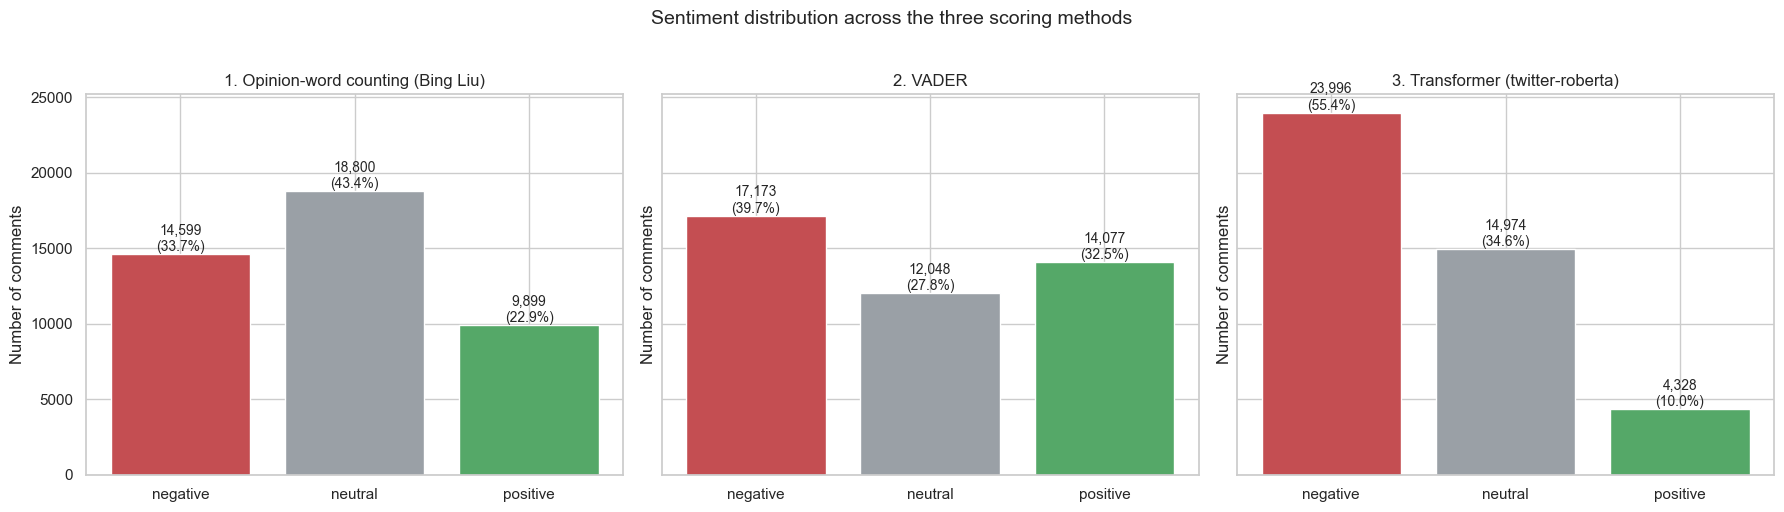

In [8]:
# Side-by-side label-share bars — one figure, one purpose.
order = ["negative", "neutral", "positive"]
colors = ["#c44e52", "#9aa0a6", "#55a868"]

methods = [
    ("lex_label", "1. Opinion-word counting (Bing Liu)"),
    ("vader_label", "2. VADER"),
    ("tx_label", "3. Transformer (twitter-roberta)"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (col, title) in zip(axes, methods):
    series = df[col].dropna()
    counts = [(series == label).sum() for label in order]
    ax.bar(order, counts, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Number of comments")
    for i, v in enumerate(counts):
        pct = v / max(len(series), 1) * 100
        ax.text(i, v, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
plt.suptitle("Sentiment distribution across the three scoring methods", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS / "sentiment_three_method_bars.png", dpi=160, bbox_inches="tight")
plt.show()


In [9]:
# Pairwise agreement % + Cohen's kappa.
#
# We compare each pair of methods on the rows that BOTH methods scored.
# If the transformer was not run (e.g. dependencies missing or skipped for
# budget), the lex-vs-VADER comparison still runs on the full corpus.
from sklearn.metrics import cohen_kappa_score

transformer_has_labels = df["tx_label"].notna().any()

rows = []
for a, b in itertools.combinations(methods, 2):
    a_col, a_name = a[0], a[1].split(" ", 1)[1]
    b_col, b_name = b[0], b[1].split(" ", 1)[1]
    sub = df.dropna(subset=[a_col, b_col])
    if len(sub) == 0 or sub[a_col].nunique() < 2 or sub[b_col].nunique() < 2:
        rows.append({"pair": f"{a_name}  vs  {b_name}",
                     "n_compared": int(len(sub)),
                     "agreement_pct": float("nan"),
                     "cohen_kappa": float("nan")})
        continue
    match = (sub[a_col] == sub[b_col])
    rows.append({"pair": f"{a_name}  vs  {b_name}",
                 "n_compared": int(len(sub)),
                 "agreement_pct": round(float(match.mean() * 100), 2),
                 "cohen_kappa": round(float(cohen_kappa_score(sub[a_col], sub[b_col])), 3)})

agreement_df = pd.DataFrame(rows)
agreement_df.to_csv(SENTIMENT_TOPICS / "sentiment_agreement_summary.csv", index=False)

print("Pairwise agreement on overlapping rows:\n")
display(agreement_df)

if transformer_has_labels:
    scored_all = df.dropna(subset=["lex_label", "vader_label", "tx_label"])
    all_three = (scored_all["lex_label"] == scored_all["vader_label"]) & \
                (scored_all["vader_label"] == scored_all["tx_label"])
    print(f"\nAll three methods agree on {all_three.mean()*100:.1f}% of overlapping comments "
          f"({all_three.sum():,} / {len(scored_all):,}).")
else:
    print("\n(Transformer labels not available in this run — three-way comparison skipped.)")
    scored_all = df.dropna(subset=["lex_label", "vader_label"]).copy()


Pairwise agreement on overlapping rows:



,pair,n_compared,agreement_pct,cohen_kappa
0,Opinion-word counting (Bing Liu) vs VADER,43298,60.04,0.405
1,Opinion-word counting (Bing Liu) vs Transformer (twitter-roberta),43298,54.84,0.294
2,VADER vs Transformer (twitter-roberta),43298,56.16,0.327



All three methods agree on 40.1% of overlapping comments (17,352 / 43,298).


In [12]:
# Persist the full sentiment table.
sentiment_columns = [
    "platform", "comment_id", "subreddit", "video_id", "channel_id", "channel_title",
    "date", "author_hash",
    "clean_text", "vader_text",
    "lex_score", "lex_pos_count", "lex_neg_count", "lex_label",
    "vader_compound", "vader_pos", "vader_neg", "vader_neu", "vader_label",
    "tx_neg", "tx_neu", "tx_pos", "tx_compound", "tx_label",
    "headline_sentiment_score", "headline_sentiment_label",
]
keep = [c for c in sentiment_columns if c in df.columns]
df[keep].to_csv(SENTIMENT_TOPICS / "sentiment_comment_level.csv", index=False)
print(f"Wrote sentiment_comment_level.csv with {len(df):,} rows and {len(keep)} columns.")


def _label_share(series, label):
    scored = series.dropna()
    return float((scored == label).mean()) if len(scored) else np.nan


# Aggregate sentiment tables for downstream use (e.g., NB7 lag correlation).
# These are now based on the configured headline method, preferably transformer.
def aggregate_sentiment(df_, by):
    if df_.empty:
        return pd.DataFrame()
    g = df_.groupby(by, dropna=False)
    return g.agg(
        n_comments=("comment_id", "size"),
        n_scored=("headline_sentiment_label", "count"),
        headline_score_mean=("headline_sentiment_score", "mean"),
        headline_score_median=("headline_sentiment_score", "median"),
        headline_score_std=("headline_sentiment_score", "std"),
        pct_positive=("headline_sentiment_label", lambda s: _label_share(s, "positive")),
        pct_negative=("headline_sentiment_label", lambda s: _label_share(s, "negative")),
        pct_neutral=("headline_sentiment_label", lambda s: _label_share(s, "neutral")),
    ).reset_index().assign(sentiment_method=HEADLINE_SENTIMENT_METHOD)


aggregate_sentiment(df, ["platform"]).to_csv(SENTIMENT_TOPICS / "sentiment_summary_by_platform.csv", index=False)
aggregate_sentiment(df, ["platform", "date"]).to_csv(SENTIMENT_TOPICS / "sentiment_summary_by_platform_date.csv", index=False)
if "subreddit" in df.columns:
    aggregate_sentiment(df[df["platform"] == "reddit"], ["subreddit"]).to_csv(
        SENTIMENT_TOPICS / "sentiment_summary_by_subreddit.csv", index=False
    )
if "channel_id" in df.columns:
    aggregate_sentiment(df[df["platform"] == "youtube"], ["channel_id"]).to_csv(
        SENTIMENT_TOPICS / "sentiment_summary_by_channel.csv", index=False
    )
print(f"Wrote headline sentiment summaries using: {HEADLINE_SENTIMENT_METHOD}")


Wrote sentiment_comment_level.csv with 43,298 rows and 25 columns.
Wrote headline sentiment summaries using: Transformer (twitter-roberta)


## 6 · Sentiment over time

Daily mean headline sentiment score and daily comment volume by platform. The
headline score is transformer `tx_compound = tx_pos - tx_neg` when transformer
labels are available. The 7-day rolling mean smooths out single-day noise. Both
series are written to disk so NB7 can run lag-correlation analysis against the
FRED jet fuel price on exactly the same daily granularity.


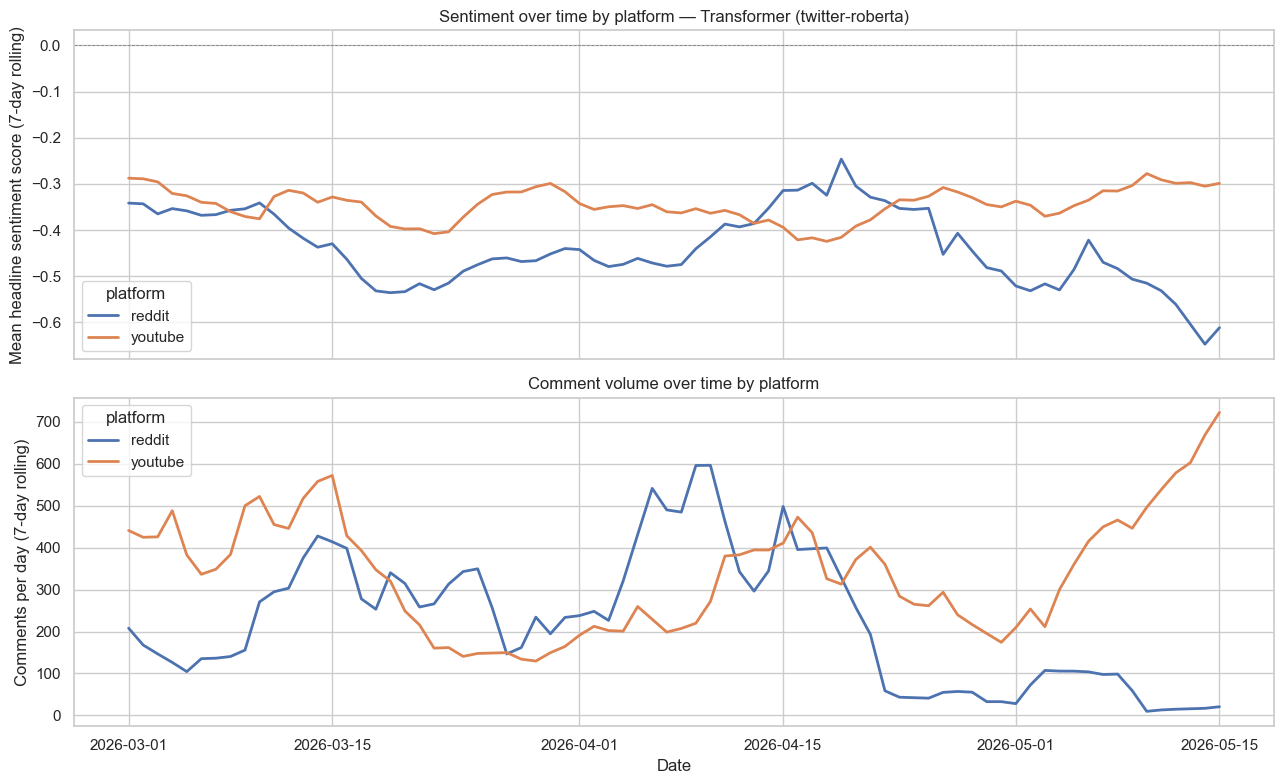

In [16]:
daily = (df.dropna(subset=["date"])
           .assign(date=lambda x: pd.to_datetime(x["date"], errors="coerce"))
           .dropna(subset=["date"])
           .groupby(["date", "platform"])
           .agg(
               n_comments=("comment_id", "size"),
               n_scored=("headline_sentiment_label", "count"),
               headline_score_mean=("headline_sentiment_score", "mean"),
               pct_negative=("headline_sentiment_label", lambda s: _label_share(s, "negative")),
           )
           .reset_index()
           .assign(sentiment_method=HEADLINE_SENTIMENT_METHOD))
daily.to_csv(SENTIMENT_TOPICS / "sentiment_daily_by_platform.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for platform, sub in daily.groupby("platform"):
    sub = sub.sort_values("date").copy()
    sub["score_smooth"] = sub["headline_score_mean"].rolling(window=7, center=True, min_periods=2).mean()
    sub["volume_smooth"] = sub["n_comments"].rolling(window=7, center=True, min_periods=2).mean()
    axes[0].plot(sub["date"], sub["score_smooth"], label=platform, linewidth=2)
    axes[1].plot(sub["date"], sub["volume_smooth"], label=platform, linewidth=2)

axes[0].axhline(0, color="grey", linewidth=0.6, linestyle="--")
axes[0].set_ylabel("Mean headline sentiment score (7-day rolling)")
axes[0].set_title(f"Sentiment over time by platform — {HEADLINE_SENTIMENT_METHOD}")
axes[0].legend(title="platform")

axes[1].set_ylabel("Comments per day (7-day rolling)")
axes[1].set_title("Comment volume over time by platform")
axes[1].set_xlabel("Date")
axes[1].legend(title="platform")

plt.tight_layout()
plt.savefig(PLOTS / "sentiment_over_time.png", dpi=160, bbox_inches="tight")
plt.show()


## 7 · Topic modelling — choosing k

The course content covers **Latent Dirichlet Allocation (LDA)** as the Week 6 topic-modelling method, so LDA is the main topic analysis tool in this notebook. LDA is fitted on raw count vectors, not TF-IDF, because its generative model assumes word counts.

We still compute an optional NMF sweep as an extension/robustness check, but NMF does **not** determine the final topic labels, prevalence tables, sentiment-by-topic analysis, or report findings.

The practical decision rule is:

1. Use the LDA perplexity sweep as the first diagnostic for candidate `k` values.
2. Inspect the top terms and representative comments for the chosen LDA topics.
3. Manually assign topic titles using the `topic_labels` dictionary in the manual topic-title section.
4. Treat any NMF result as a secondary comparison only, especially if it prefers a different number of topics.


In [19]:
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Local topic-stopword list. Some overlap with NB1/NB2 domain stopwords is
# intentional — NB1/NB2 keep the corpus general, while this list strips generic
# conversational fillers that would otherwise dominate topics.
TOPIC_EXTRA_STOPWORDS = sorted({
    "also", "could", "even", "get", "going", "got", "know", "like",
    "make", "much", "need", "one", "people", "really", "right", "said", "say",
    "see", "still", "thing", "think", "time", "two", "use", "used", "using",
    "want", "way", "well", "would", "that's", "i'm", "don't", "can't", "it's", "you're", "they're",
    "getting", "always", "never", "nothing", "anything", "everything", "someone", "somebody",
})

SENTIMENT_ORDER = ["negative", "neutral", "positive"]
PLATFORMS_FOR_TOPICS = [p for p in ["reddit", "youtube"] if p in df["platform"].dropna().unique()]


def _adaptive_min_df(n_docs, requested=5):
    """Keep min_df sensible for smaller platform-specific corpora."""
    if n_docs < 100:
        return 2
    return min(requested, max(2, n_docs // 200)) if n_docs < 1000 else requested


def _vectorize_tfidf(texts, max_features=5000, min_df=5, ngram_range=(1, 2), stop_words=None):
    vec = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=0.95,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[a-z][a-z\-']{2,}\b",
        stop_words=stop_words,
    )
    return vec, vec.fit_transform(texts)


def _vectorize_counts(texts, max_features=5000, min_df=5, ngram_range=(1, 2), stop_words=None):
    vec = CountVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=0.95,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[a-z][a-z\-']{2,}\b",
        stop_words=stop_words,
    )
    return vec, vec.fit_transform(texts)


def topic_coherence_umass(topic_terms, matrix, vocab, top_n=10, epsilon=1.0):
    """Simple UMass-style coherence from the document-term matrix."""
    binary = (matrix > 0).astype(int)
    vocab_index = {term: idx for idx, term in enumerate(vocab)}
    per_topic = []
    for terms in topic_terms:
        idx = [vocab_index[t] for t in terms[:top_n] if t in vocab_index]
        if len(idx) < 2:
            continue
        sub = binary[:, idx]
        co = (sub.T @ sub).toarray()
        df_local = co.diagonal().astype(float)
        score, pairs = 0.0, 0
        for i in range(len(idx)):
            for j in range(i):
                num = co[i, j] + epsilon
                den = df_local[j] if df_local[j] > 0 else 1.0
                score += float(np.log(num / den))
                pairs += 1
        if pairs:
            per_topic.append(score / pairs)
    return float(np.mean(per_topic)) if per_topic else float("nan")


def top_words_per_topic(components, vocab, n_top=15):
    rows = []
    for tid, row in enumerate(components):
        top_idx = row.argsort()[-n_top:][::-1]
        rows.append({
            "topic_id": int(tid),
            "top_terms": ", ".join(vocab[top_idx]),
            "terms": vocab[top_idx],
            "weights": row[top_idx],
        })
    return rows


def plot_topic_bars(topic_rows, platform, model_name, filename_prefix, n_cols=2):
    """Per-topic horizontal bar charts for one platform/model."""
    n_topics = len(topic_rows)
    n_rows = (n_topics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, max(4 * n_rows, 4)))
    axes = np.atleast_1d(axes).flatten()
    for tid, row in enumerate(topic_rows):
        ax = axes[tid]
        terms = row["terms"][::-1]
        weights = row["weights"][::-1]
        ax.barh(range(len(terms)), weights)
        ax.set_yticks(range(len(terms)))
        ax.set_yticklabels(terms)
        ax.set_title(f"{platform.title()} {model_name} topic {row['topic_id']}", fontsize=11)
        ax.set_xlabel("topic-term weight")
    for j in range(n_topics, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(PLOTS / f"{filename_prefix}_{platform}.png", dpi=160, bbox_inches="tight")
    plt.show()


Reddit topic corpus: 17,162 non-empty comments
Youtube topic corpus: 26,136 non-empty comments
Local topic stopwords (45): also, always, anything, can't, could, don't, even, everything, get, getting, going, got ...

Reddit: min_df=5, candidate k=[3, 4, 5, 6, 7, 8]

Youtube: min_df=5, candidate k=[3, 4, 5, 6, 7, 8]


,platform,k,perplexity
0,reddit,3,2188.984081
1,reddit,4,2345.793550
2,reddit,5,2438.378057
3,reddit,6,2538.401543
4,reddit,7,2617.972651
5,reddit,8,2690.855196
6,youtube,3,2025.161119
7,youtube,4,2064.265517
8,youtube,5,2193.515115
9,youtube,6,2322.506770


,platform,k,umass_coherence
0,reddit,3,-2.854132
1,reddit,4,-2.935511
2,reddit,5,-2.968201
3,reddit,6,-2.938217
4,reddit,7,-2.934957
5,reddit,8,-2.941486
6,youtube,3,-2.955943
7,youtube,4,-2.944497
8,youtube,5,-3.092547
9,youtube,6,-3.239427


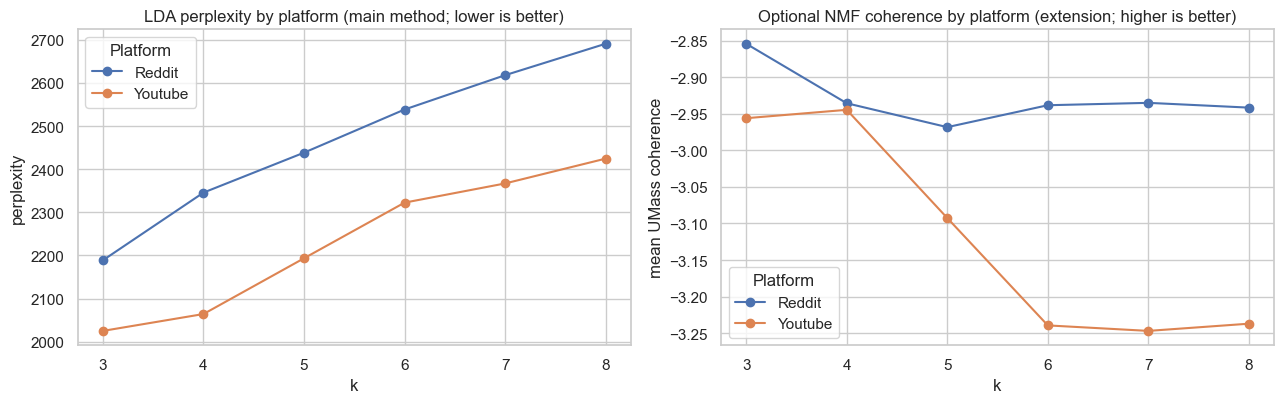


Selected k values:
LDA main method: {'reddit': 3, 'youtube': 3}
NMF optional comparison: {'reddit': 3, 'youtube': 4}


In [20]:
# Build one topic corpus per platform.
topic_corpus = {}
for platform in PLATFORMS_FOR_TOPICS:
    sub = df[(df["platform"] == platform) & (df["lemma_text"].fillna("").str.len() > 0)].copy()
    sub = sub.reset_index(drop=True)
    topic_corpus[platform] = sub
    print(f"{platform.title()} topic corpus: {len(sub):,} non-empty comments")

print(f"Local topic stopwords ({len(TOPIC_EXTRA_STOPWORDS)}): {', '.join(TOPIC_EXTRA_STOPWORDS[:12])} ...")

# Candidate k values. The effective list is capped by each platform's sample size.
K_VALUES = [3, 4, 5, 6, 7, 8]

topic_k_sweeps = {}
topic_vector_spaces = {}

for platform, sub in topic_corpus.items():
    texts = sub["lemma_text"].fillna("").astype(str).tolist()
    n_docs = len(texts)
    if n_docs < 50:
        print(f"Skipping {platform}: too few comments for topic modelling ({n_docs}).")
        continue

    min_df = _adaptive_min_df(n_docs, requested=5)
    valid_k = [k for k in K_VALUES if k < max(3, n_docs // 10)] or [2]
    print(f"\n{platform.title()}: min_df={min_df}, candidate k={valid_k}")

    # LDA perplexity sweep: course-aligned main diagnostic.
    vec_counts, X_counts = _vectorize_counts(texts, min_df=min_df, stop_words=TOPIC_EXTRA_STOPWORDS)
    vocab_counts = np.array(vec_counts.get_feature_names_out())
    lda_rows = []
    for k in valid_k:
        model = LatentDirichletAllocation(
            n_components=int(k), max_iter=15, learning_method="online",
            random_state=0, n_jobs=1,
        )
        model.fit(X_counts)
        lda_rows.append({
            "platform": platform,
            "k": int(k),
            "perplexity": float(model.perplexity(X_counts)),
        })
    lda_sweep = pd.DataFrame(lda_rows)

    # Optional NMF extension: useful as a comparison, not as the headline method.
    vec_tfidf, X_tfidf = _vectorize_tfidf(texts, min_df=min_df, stop_words=TOPIC_EXTRA_STOPWORDS)
    vocab_tfidf = np.array(vec_tfidf.get_feature_names_out())
    nmf_rows = []
    for k in valid_k:
        model = NMF(n_components=int(k), random_state=0, init="nndsvda", max_iter=500)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*encountered in matmul", category=RuntimeWarning)
            warnings.filterwarnings("ignore", message=".*encountered in sqrt", category=RuntimeWarning)
            model.fit(X_tfidf)
        topic_terms = [
            vocab_tfidf[np.argsort(model.components_[t])[::-1][:10]].tolist()
            for t in range(model.n_components_)
        ]
        nmf_rows.append({
            "platform": platform,
            "k": int(k),
            "umass_coherence": topic_coherence_umass(topic_terms, X_tfidf, vocab_tfidf, top_n=10),
        })
    nmf_sweep = pd.DataFrame(nmf_rows)

    topic_k_sweeps[platform] = {"lda": lda_sweep, "nmf": nmf_sweep}
    topic_vector_spaces[platform] = {
        "count_vectorizer": vec_counts,
        "count_matrix": X_counts,
        "count_vocab": vocab_counts,
        "tfidf_vectorizer": vec_tfidf,
        "tfidf_matrix": X_tfidf,
        "tfidf_vocab": vocab_tfidf,
        "min_df": min_df,
    }

# Persist sweep tables.
all_lda_sweeps = pd.concat([v["lda"] for v in topic_k_sweeps.values()], ignore_index=True)
all_nmf_sweeps = pd.concat([v["nmf"] for v in topic_k_sweeps.values()], ignore_index=True)
all_lda_sweeps.to_csv(SENTIMENT_TOPICS / "topics_platform_lda_k_sweep.csv", index=False)
all_nmf_sweeps.to_csv(SENTIMENT_TOPICS / "topics_platform_nmf_k_sweep_optional.csv", index=False)
all_nmf_sweeps.to_csv(SENTIMENT_TOPICS / "topics_platform_nmf_k_sweep.csv", index=False)

display(all_lda_sweeps)
display(all_nmf_sweeps)

# Diagnostic plots: LDA first because it is the main course-aligned method.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for platform in topic_k_sweeps:
    lda_sweep = topic_k_sweeps[platform]["lda"]
    nmf_sweep = topic_k_sweeps[platform]["nmf"]
    axes[0].plot(lda_sweep["k"], lda_sweep["perplexity"], marker="o", label=platform.title())
    axes[1].plot(nmf_sweep["k"], nmf_sweep["umass_coherence"], marker="o", label=platform.title())
axes[0].set_title("LDA perplexity by platform (main method; lower is better)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("perplexity")
axes[1].set_title("Optional NMF coherence by platform (extension; higher is better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean UMass coherence")
for ax in axes:
    ax.legend(title="Platform")
plt.tight_layout()
plt.savefig(PLOTS / "topic_model_k_diagnostics_by_platform.png", dpi=160, bbox_inches="tight")
plt.show()

BEST_K_LDA_BY_PLATFORM = {
    platform: int(sweeps["lda"].loc[sweeps["lda"]["perplexity"].idxmin(), "k"])
    for platform, sweeps in topic_k_sweeps.items()
}
BEST_K_NMF_BY_PLATFORM = {
    platform: int(sweeps["nmf"].loc[sweeps["nmf"]["umass_coherence"].idxmax(), "k"])
    for platform, sweeps in topic_k_sweeps.items()
}

print("\nSelected k values:")
print("LDA main method:", BEST_K_LDA_BY_PLATFORM)
print("NMF optional comparison:", BEST_K_NMF_BY_PLATFORM)


**Decision log.** The LDA `k` selected by minimum perplexity is used for the headline topic model because LDA is the Week 6 course method. NMF may prefer a different `k`; that difference is expected because NMF factorises a TF-IDF matrix rather than modelling word-count topic mixtures. NMF is therefore retained only as an optional robustness comparison, not as the basis for the final topic analysis.


## 8 · LDA at the chosen k (headline topic model)

LDA is the main topic-modelling method in this notebook. For each platform, we fit LDA at the selected `k`, inspect the top terms, assign each comment to its dominant LDA topic, and save the topic summary tables used by the rest of the notebook.

The topic labels are not automatic. They are assigned manually after inspecting top terms and representative comments after inspecting the top terms and representative comments.



Reddit LDA topics before manual labelling:


,platform,topic_id,top_terms,doc_count,avg_headline_sentiment,mean_topic_probability,dominant_sources,representative_comments
0,reddit,1,"market, trump, price, money, american, stock, lol, enough, yeah, gas, news, day, actually, point, every",6594,-0.382669,0.686698,"{""stocks"": 1249, ""worldnews"": 1183, ""investing"": 953, ""oil"": 821, ""energy"": 775}","[""until it isn't. if you've been investing for awhile, i strongly recommend reading \""a random walk down wall street\"" by burton malkiel. specifically the c..."
1,reddit,2,"iran, usa, war, country, israel, trump, world, iranian, military, china, attack, america, power, state, deal",5694,-0.535694,0.693747,"{""worldnews"": 1302, ""geopolitics"": 1177, ""oil"": 978, ""stocks"": 691, ""energy"": 600}","[""it's actually not like vietnam at all. vietnam resulted in the deaths of millions of americans and vietnamese. that war was way larger and it was a huge f..."
2,reddit,0,"oil, strait, ship, open, china, week, hormuz, something, trump, day, price, iran, guy, already, closed",4874,-0.284767,0.634123,"{""worldnews"": 857, ""oil"": 845, ""wallstreetbets"": 787, ""stocks"": 663, ""energy"": 618}","[""the usa consumes >20 million barrels per day in 2024, that's roughly 7.3 billion barrels per year. it has 415 million barrels of reserve in mid march 2026..."


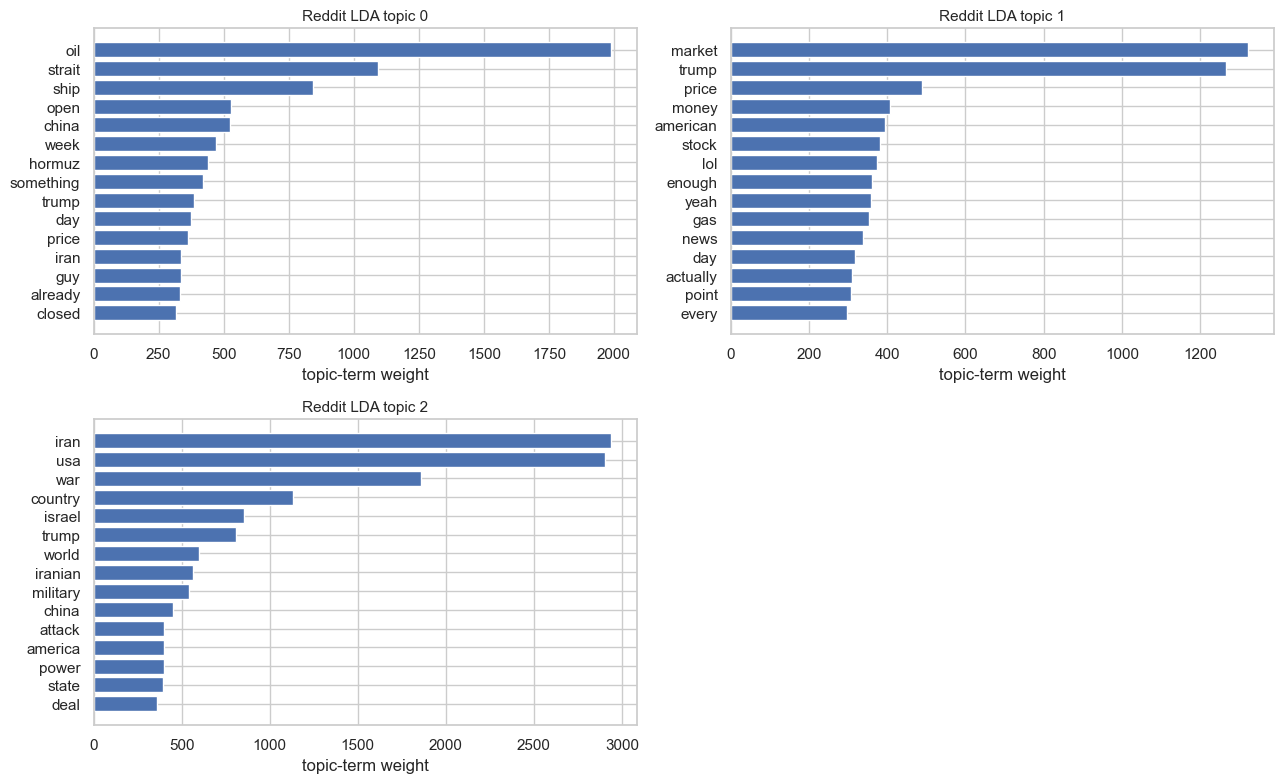


Youtube LDA topics before manual labelling:


,platform,topic_id,top_terms,doc_count,avg_headline_sentiment,mean_topic_probability,dominant_sources,representative_comments
0,youtube,1,"iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country, military, american, attack, regime, president",10294,-0.415784,0.676181,"{""D8mw3SCKfeE"": 306, ""T2WxWBNXB-Y"": 275, ""2Nu4qbbOj2M"": 259, ""Bn8v59ZERhU"": 257, ""YPIkNV9D3Hk"": 255}","[""just a few of the msm headlines within the last hour- cnn- \""iran threatens usa forces in strait of hormuz\"" bbc- \""iran threatens to attack usa forces in..."
1,youtube,0,"world, china, trump, america, usa, country, american, state, gulf, tanker, great, russia, power, stop, control",8384,-0.290456,0.614041,"{""ds46PwOUy2g"": 257, ""ptRGY5xHIGg"": 254, ""BpHhN0vqP0k"": 232, ""mNjVZCmf-D4"": 199, ""ruOkuy3Tqv0"": 191}","[""if the united states withdraws from nato. russia and china would never agree to help nato when they benefit greatly from the downfall of nato. nato needs ..."
2,youtube,2,"oil, price, gas, year, fuel, india, usa, news, market, energy, uae, cost, ship, global, supply",7458,-0.306736,0.683636,"{""ICBjPCfOTn4"": 311, ""YWc8vMTkgK0"": 311, ""_I1yJ5g33OQ"": 256, ""7Di5PTCsf5I"": 230, ""K9kNiVLrudM"": 230}","[""one of the levers are wholesale gas prices on the market are inventory levels, currently gasoline is 4% below the five year average. that puts a lot of up..."


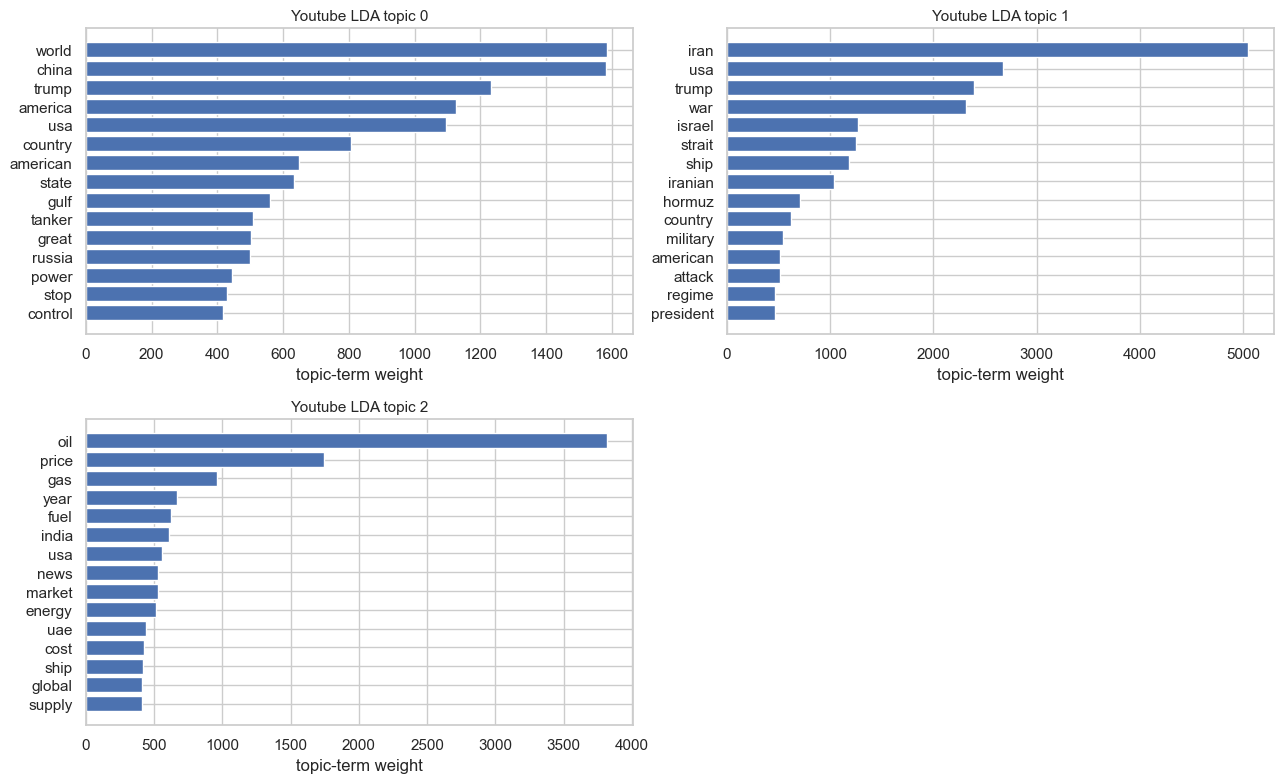

In [21]:
def summarise_lda_platform_topics(df_, lda_model, doc_topic, vocab, platform,
                                  sentiment_col="headline_sentiment_score",
                                  top_terms_n=15, rep_docs_n=5):
    """Create LDA topic summaries and dominant-topic assignments for one platform."""
    components = lda_model.components_
    topic_word_prob = components / components.sum(axis=1, keepdims=True)
    n_topics_ = components.shape[0]
    dominant = doc_topic.argmax(axis=1)

    df_local = df_.reset_index(drop=True).copy()
    df_local["platform_topic_id"] = dominant
    df_local["topic_probability"] = doc_topic[np.arange(len(df_local)), dominant]
    # Generic alias used by downstream plotting code. For LDA this is a posterior topic probability.
    df_local["topic_weight"] = df_local["topic_probability"]

    summary_rows = []
    for tid in range(n_topics_):
        top_idx = np.argsort(topic_word_prob[tid])[::-1][:top_terms_n]
        top_terms = vocab[top_idx].tolist()
        members = df_local[df_local["platform_topic_id"] == tid]
        rep = members.sort_values("topic_probability", ascending=False).head(rep_docs_n)
        avg_sent = float(members[sentiment_col].mean()) if sentiment_col in members.columns and len(members) else None

        if platform == "reddit" and "subreddit" in members.columns:
            dominant_source = json.dumps(members["subreddit"].value_counts().head(5).to_dict())
            source_col = "subreddit"
        elif platform == "youtube":
            video_col = "video_title" if "video_title" in members.columns else "video_id"
            dominant_source = json.dumps(members[video_col].value_counts().head(5).to_dict()) if video_col in members.columns else "{}"
            source_col = video_col
        else:
            dominant_source = "{}"
            source_col = None

        summary_rows.append({
            "platform": platform,
            "topic_id": int(tid),
            "platform_topic": f"{platform}_topic_{tid}",
            "top_terms": ", ".join(top_terms),
            "doc_count": int(len(members)),
            "avg_headline_sentiment": avg_sent,
            "mean_topic_probability": float(members["topic_probability"].mean()) if len(members) else np.nan,
            "mean_dominant_weight": float(members["topic_weight"].mean()) if len(members) else np.nan,
            "dominant_source_col": source_col,
            "dominant_sources": dominant_source,
            "representative_comments": json.dumps(rep["clean_text"].fillna("").tolist(), ensure_ascii=False),
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("doc_count", ascending=False).reset_index(drop=True)

    dominant_df = df_local[["comment_id", "platform", "platform_topic_id", "topic_probability", "topic_weight"]].copy()
    dominant_df["platform_topic"] = dominant_df["platform"] + "_topic_" + dominant_df["platform_topic_id"].astype(str)

    long_rows = []
    for col in range(n_topics_):
        weights = doc_topic[:, col]
        for i, weight in enumerate(weights):
            long_rows.append({
                "comment_id": df_local.iloc[i].get("comment_id"),
                "platform": platform,
                "topic_id": int(col),
                "platform_topic": f"{platform}_topic_{col}",
                "topic_probability": float(weight),
                "topic_weight": float(weight),
            })
    return summary_df, dominant_df, pd.DataFrame(long_rows)


lda_platform_results = {}
lda_summaries = []
lda_dominant_frames = []
lda_doc_topic_frames = []
lda_top_terms_all = []

for platform, sub in topic_corpus.items():
    if platform not in BEST_K_LDA_BY_PLATFORM:
        continue

    spaces = topic_vector_spaces[platform]
    X_counts = spaces["count_matrix"]
    vocab_counts = spaces["count_vocab"]
    k = BEST_K_LDA_BY_PLATFORM[platform]

    lda_model = LatentDirichletAllocation(
        n_components=k, max_iter=50, learning_method="online",
        random_state=0, n_jobs=1,
    )
    lda_doc_topic = lda_model.fit_transform(X_counts)
    lda_rows = top_words_per_topic(lda_model.components_, vocab_counts, n_top=15)
    summary_df, dominant_df, doc_topic_df = summarise_lda_platform_topics(
        sub, lda_model, lda_doc_topic, vocab_counts, platform
    )

    top_terms_df = pd.DataFrame([
        {"platform": platform, "topic_id": row["topic_id"], "top_terms": row["top_terms"]}
        for row in lda_rows
    ])
    top_terms_df.to_csv(SENTIMENT_TOPICS / f"topics_lda_{platform}_top_terms.csv", index=False)
    summary_df.to_csv(SENTIMENT_TOPICS / f"topics_lda_{platform}_summary_unlabelled.csv", index=False)
    dominant_df.to_csv(SENTIMENT_TOPICS / f"topics_lda_{platform}_dominant_per_comment.csv", index=False)
    doc_topic_df.to_csv(SENTIMENT_TOPICS / f"topics_lda_{platform}_doc_topic_long.csv", index=False)

    lda_platform_results[platform] = {
        "model": lda_model,
        "doc_topic": lda_doc_topic,
        "topic_rows": lda_rows,
        "summary": summary_df,
        "dominant": dominant_df,
        "doc_topic_long": doc_topic_df,
    }
    lda_top_terms_all.append(top_terms_df)
    lda_summaries.append(summary_df)
    lda_dominant_frames.append(dominant_df)
    lda_doc_topic_frames.append(doc_topic_df)

    print(f"\n{platform.title()} LDA topics before manual labelling:")
    display(summary_df[["platform", "topic_id", "top_terms", "doc_count",
                        "avg_headline_sentiment", "mean_topic_probability",
                        "dominant_sources", "representative_comments"]])
    plot_topic_bars(lda_rows, platform, "LDA", "topic_lda_per_topic_bars")

lda_top_terms_platform = pd.concat(lda_top_terms_all, ignore_index=True)
lda_summary_platform = pd.concat(lda_summaries, ignore_index=True)
dominant_platform_topics = pd.concat(lda_dominant_frames, ignore_index=True)
lda_doc_topic_platform = pd.concat(lda_doc_topic_frames, ignore_index=True)

lda_top_terms_platform.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_top_terms.csv", index=False)
lda_summary_platform.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_summary_unlabelled.csv", index=False)
dominant_platform_topics.to_csv(SENTIMENT_TOPICS / "topics_platform_dominant_per_comment.csv", index=False)
lda_doc_topic_platform.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_doc_topic_long.csv", index=False)


## 9 · Manual platform-specific topic titles for LDA

The Reddit and YouTube LDA models are fitted separately, so their numeric
`topic_id` values are **not shared meanings**. Reddit topic `0` and YouTube topic
`0` can describe different frames.

The dictionaries below are therefore platform-specific. They are the only place
where human-readable topic titles are assigned. Edit them after inspecting each
platform's top terms and representative comments.


In [32]:
# Numeric topic IDs are stored in the `topic_id` column of each LDA topic summary table.
# These labels are platform-specific because Reddit and YouTube LDA models are fitted separately.
reddit_lda_topic_labels = {
    0: "Strait of Hormuz and oil-market disruption",
    1: "Trump, markets, and US economic reaction",
    2: "Iran-US geopolitical conflict and war risk",
}

youtube_lda_topic_labels = {
    0: "Global power politics and US-China rivalry",
    1: "Iran-US conflict, Israel, and military escalation",
    2: "Oil, gas prices, and global energy supply", 
}

lda_topic_labels_by_platform = {
    "reddit": reddit_lda_topic_labels,
    "youtube": youtube_lda_topic_labels,
}


def manual_topic_label(platform, topic_id):
    """Return the manually assigned title for a platform-specific numeric topic ID."""
    try:
        topic_id = int(topic_id)
    except (TypeError, ValueError):
        return f"Topic {topic_id}"
    platform_labels = lda_topic_labels_by_platform.get(str(platform).lower(), {})
    return platform_labels.get(topic_id, f"Topic {topic_id}")


def apply_manual_topic_labels(summary_df, topic_id_col="topic_id", platform_col="platform"):
    if topic_id_col not in summary_df.columns:
        raise KeyError(f"Expected topic ID column {topic_id_col!r} in the topic summary table")
    if platform_col not in summary_df.columns:
        raise KeyError(f"Expected platform column {platform_col!r} in the topic summary table")
    out = summary_df.copy()
    out["topic_label"] = out.apply(lambda r: manual_topic_label(r[platform_col], r[topic_id_col]), axis=1)
    out["topic_title"] = out["topic_label"]
    out["platform_topic_label"] = out["platform"].str.title() + " - " + out["topic_label"]
    return out


labelled_platform_topics = apply_manual_topic_labels(lda_summary_platform, topic_id_col="topic_id")
labelled_platform_topics.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_labelled.csv", index=False)

label_lookup = labelled_platform_topics.set_index("platform_topic")["topic_label"].to_dict()
dominant_with_label = dominant_platform_topics.copy()
dominant_with_label["topic_label"] = dominant_with_label.apply(
    lambda r: manual_topic_label(r["platform"], r["platform_topic_id"]), axis=1
)
dominant_with_label["topic_title"] = dominant_with_label["topic_label"]
dominant_with_label["platform_topic_label"] = dominant_with_label["platform"].str.title() + " - " + dominant_with_label["topic_label"]
dominant_with_label.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_dominant_per_comment_labelled.csv", index=False)
dominant_with_label.to_csv(SENTIMENT_TOPICS / "topics_platform_dominant_per_comment_labelled.csv", index=False)

print("Platform-specific LDA topics with manually assigned titles:")
display(labelled_platform_topics[["platform", "topic_id", "topic_label", "top_terms",
                                  "doc_count", "avg_headline_sentiment",
                                  "mean_topic_probability"]])


Platform-specific LDA topics with manually assigned titles:


,platform,topic_id,topic_label,top_terms,doc_count,avg_headline_sentiment,mean_topic_probability
0,reddit,1,"Trump, markets, and US economic reaction","market, trump, price, money, american, stock, lol, enough, yeah, gas, news, day, actually, point, every",6594,-0.382669,0.686698
1,reddit,2,Iran-US geopolitical conflict and war risk,"iran, usa, war, country, israel, trump, world, iranian, military, china, attack, america, power, state, deal",5694,-0.535694,0.693747
2,reddit,0,Strait of Hormuz and oil-market disruption,"oil, strait, ship, open, china, week, hormuz, something, trump, day, price, iran, guy, already, closed",4874,-0.284767,0.634123
3,youtube,1,"Iran-US conflict, Israel, and military escalation","iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country, military, american, attack, regime, president",10294,-0.415784,0.676181
4,youtube,0,Global power politics and US-China rivalry,"world, china, trump, america, usa, country, american, state, gulf, tanker, great, russia, power, stop, control",8384,-0.290456,0.614041
5,youtube,2,"Oil, gas prices, and global energy supply","oil, price, gas, year, fuel, india, usa, news, market, energy, uae, cost, ship, global, supply",7458,-0.306736,0.683636


## 10 · Comparing Reddit and YouTube LDA topics

Because the LDA models are fitted separately for Reddit and YouTube, topic numbers are not assumed to be identical across platforms. The comparison below matches Reddit topics to YouTube topics using top-term Jaccard overlap. This keeps the comparison transparent while preserving the platform-specific models.


Reddit -> YouTube LDA topic matches based on top-10 Jaccard overlap:


,reddit_topic,reddit_label,reddit_top10,best_youtube_topic,youtube_label,youtube_top10,jaccard_top10,shared_terms
2,reddit_topic_2,Iran-US geopolitical conflict and war risk,"iran, usa, war, country, israel, trump, world, iranian, military, china",youtube_topic_1,"Iran-US conflict, Israel, and military escalation","iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country",0.538,"country, iran, iranian, israel, trump, usa, war"
0,reddit_topic_0,Strait of Hormuz and oil-market disruption,"oil, strait, ship, open, china, week, hormuz, something, trump, day",youtube_topic_1,"Iran-US conflict, Israel, and military escalation","iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country",0.250,"hormuz, ship, strait, trump"
1,reddit_topic_1,"Trump, markets, and US economic reaction","market, trump, price, money, american, stock, lol, enough, yeah, gas",youtube_topic_2,"Oil, gas prices, and global energy supply","oil, price, gas, year, fuel, india, usa, news, market, energy",0.176,"gas, market, price"


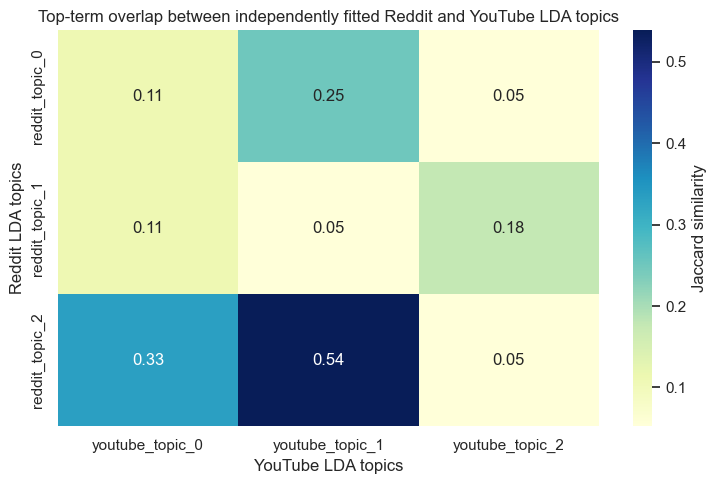

In [33]:
def platform_topic_term_sets(platform, n_top=10):
    result = lda_platform_results[platform]
    rows = []
    for row in result["topic_rows"]:
        tid = int(row["topic_id"])
        terms = [str(t) for t in row["terms"][:n_top]]
        rows.append({
            "platform": platform,
            "topic_id": tid,
            "platform_topic": f"{platform}_topic_{tid}",
            "topic_label": label_lookup.get(f"{platform}_topic_{tid}", manual_topic_label(platform, tid)),
            "top_terms": terms,
            "term_set": set(terms),
        })
    return rows

comparison_rows = []
similarity_matrix = None

if {"reddit", "youtube"}.issubset(lda_platform_results):
    reddit_terms = platform_topic_term_sets("reddit", n_top=10)
    youtube_terms = platform_topic_term_sets("youtube", n_top=10)

    sim = pd.DataFrame(
        index=[r["platform_topic"] for r in reddit_terms],
        columns=[y["platform_topic"] for y in youtube_terms],
        dtype=float,
    )

    for r in reddit_terms:
        scored = []
        for y in youtube_terms:
            union = r["term_set"] | y["term_set"]
            shared = r["term_set"] & y["term_set"]
            jaccard = len(shared) / len(union) if union else 0.0
            sim.loc[r["platform_topic"], y["platform_topic"]] = jaccard
            scored.append((jaccard, y, shared))
        scored.sort(key=lambda x: x[0], reverse=True)
        best_jaccard, best_youtube, shared = scored[0]
        comparison_rows.append({
            "reddit_topic": r["platform_topic"],
            "reddit_label": r["topic_label"],
            "reddit_top10": ", ".join(r["top_terms"]),
            "best_youtube_topic": best_youtube["platform_topic"],
            "youtube_label": best_youtube["topic_label"],
            "youtube_top10": ", ".join(best_youtube["top_terms"]),
            "jaccard_top10": round(float(best_jaccard), 3),
            "shared_terms": ", ".join(sorted(shared)),
        })

    similarity_matrix = sim
    topic_platform_alignment = pd.DataFrame(comparison_rows).sort_values("jaccard_top10", ascending=False)
    topic_platform_alignment.to_csv(SENTIMENT_TOPICS / "topics_lda_reddit_youtube_alignment.csv", index=False)
    topic_platform_alignment.to_csv(SENTIMENT_TOPICS / "topics_reddit_youtube_alignment.csv", index=False)
    similarity_matrix.to_csv(SENTIMENT_TOPICS / "topics_lda_reddit_youtube_similarity_matrix.csv")

    print("Reddit -> YouTube LDA topic matches based on top-10 Jaccard overlap:")
    display(topic_platform_alignment)

    fig, ax = plt.subplots(figsize=(max(7, 1.2 * similarity_matrix.shape[1] + 4),
                                    max(5, 0.55 * similarity_matrix.shape[0] + 3)))
    sns.heatmap(similarity_matrix.astype(float), annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
                cbar_kws={"label": "Jaccard similarity"})
    ax.set_title("Top-term overlap between independently fitted Reddit and YouTube LDA topics")
    ax.set_xlabel("YouTube LDA topics")
    ax.set_ylabel("Reddit LDA topics")
    plt.tight_layout()
    plt.savefig(PLOTS / "topics_lda_reddit_youtube_jaccard_heatmap.png", dpi=160, bbox_inches="tight")
    plt.savefig(PLOTS / "topics_reddit_youtube_jaccard_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    topic_platform_alignment = pd.DataFrame()
    print("Need both Reddit and YouTube LDA models to compute cross-platform topic alignment.")


## 11 · LDA topic prevalence by platform

Which LDA topics dominate, and which platforms / subreddits / channels lean into each topic? The platform view is the headline comparison; the subreddit / channel heatmaps show within-platform variation that the platform-level number averages away.


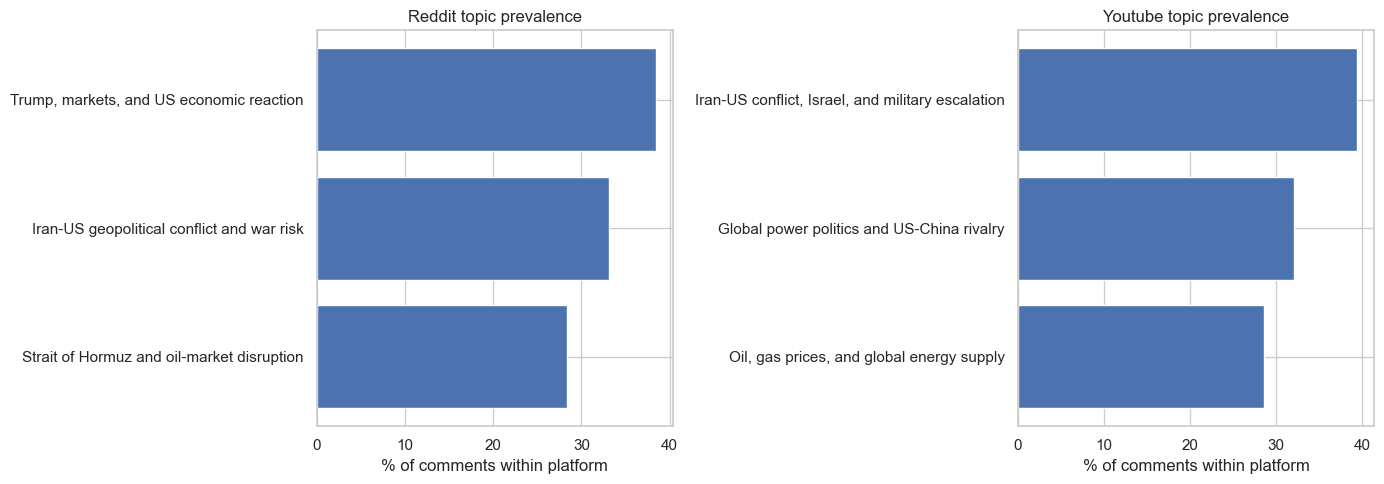

,platform,topic_label,comments,pct_within_platform
0,reddit,"Trump, markets, and US economic reaction",6594,38.4
1,reddit,Iran-US geopolitical conflict and war risk,5694,33.2
2,reddit,Strait of Hormuz and oil-market disruption,4874,28.4
3,youtube,"Iran-US conflict, Israel, and military escalation",10294,39.4
4,youtube,Global power politics and US-China rivalry,8384,32.1
5,youtube,"Oil, gas prices, and global energy supply",7458,28.5


In [35]:
# Topic prevalence within each platform.
prevalence_rows = []
for platform in PLATFORMS_FOR_TOPICS:
    sub = dominant_with_label[dominant_with_label["platform"] == platform]
    counts = sub["topic_label"].value_counts()
    pct = counts / counts.sum() * 100
    for label, count in counts.items():
        prevalence_rows.append({
            "platform": platform,
            "topic_label": label,
            "comments": int(count),
            "pct_within_platform": float(pct.loc[label]),
        })

topic_prevalence_platform_specific = pd.DataFrame(prevalence_rows)
topic_prevalence_platform_specific.to_csv(SENTIMENT_TOPICS / "topic_prevalence_platform_specific.csv", index=False)

fig, axes = plt.subplots(1, len(PLATFORMS_FOR_TOPICS), figsize=(7 * len(PLATFORMS_FOR_TOPICS), 5), sharex=False)
axes = np.atleast_1d(axes)

for ax, platform in zip(axes, PLATFORMS_FOR_TOPICS):
    sub = topic_prevalence_platform_specific[topic_prevalence_platform_specific["platform"] == platform]
    sub = sub.sort_values("pct_within_platform", ascending=True)
    ax.barh(sub["topic_label"], sub["pct_within_platform"])
    ax.set_title(f"{platform.title()} topic prevalence")
    ax.set_xlabel("% of comments within platform")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(PLOTS / "topic_prevalence_platform_specific.png", dpi=160, bbox_inches="tight")
plt.show()

display(topic_prevalence_platform_specific.sort_values(["platform", "pct_within_platform"], ascending=[True, False]).round(1))


## 12 · Transformer sentiment composition by LDA topic

Each platform-specific LDA topic is crossed with the configured **headline**
sentiment method. In the preferred final run this is transformer sentiment
(`tx_label`, `tx_compound`), not VADER. This is the table/plot to use when arguing
which LDA topics carry the most negative tone.

VADER remains available in the earlier comparison cells as a course-aligned
baseline, but it is no longer the main topic-sentiment measure.


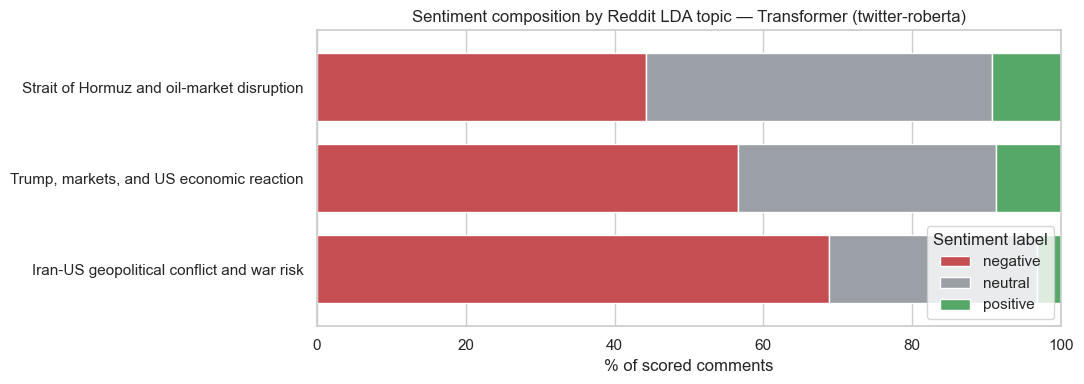

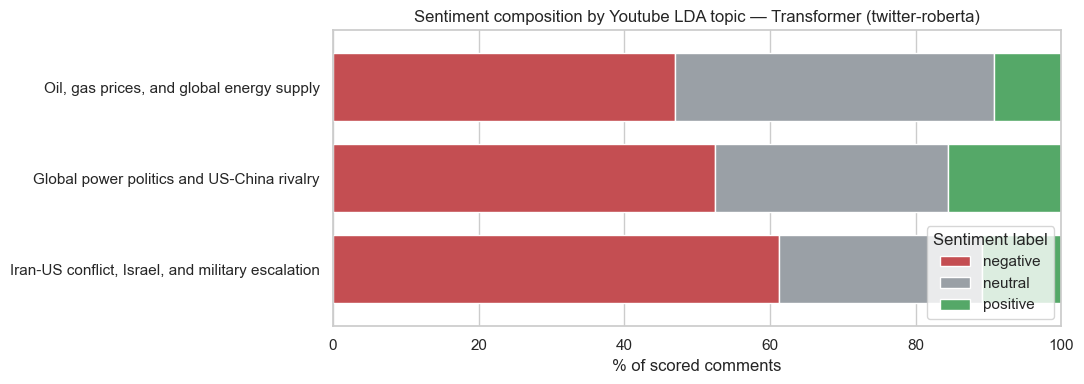

Platform-specific LDA topic-sentiment summary using Transformer (twitter-roberta):


,platform,platform_topic,topic_label,comments,scored_comments,mean_headline_sentiment,median_headline_sentiment,pct_negative,pct_neutral,pct_positive,mean_transformer_compound,mean_vader_compound,mean_topic_probability,sentiment_method
2,reddit,reddit_topic_2,Iran-US geopolitical conflict and war risk,5694,5694,-0.536,-0.665,0.689,0.278,0.033,-0.535694,-0.179,0.694,Transformer (twitter-roberta)
1,reddit,reddit_topic_1,"Trump, markets, and US economic reaction",6594,6594,-0.383,-0.525,0.565,0.347,0.087,-0.382669,-0.001,0.687,Transformer (twitter-roberta)
0,reddit,reddit_topic_0,Strait of Hormuz and oil-market disruption,4874,4874,-0.285,-0.340,0.443,0.464,0.093,-0.284767,0.015,0.634,Transformer (twitter-roberta)
4,youtube,youtube_topic_1,"Iran-US conflict, Israel, and military escalation",10294,10294,-0.416,-0.614,0.612,0.280,0.108,-0.415784,-0.122,0.676,Transformer (twitter-roberta)
3,youtube,youtube_topic_0,Global power politics and US-China rivalry,8384,8384,-0.290,-0.455,0.524,0.320,0.156,-0.290456,-0.002,0.614,Transformer (twitter-roberta)
5,youtube,youtube_topic_2,"Oil, gas prices, and global energy supply",7458,7458,-0.307,-0.370,0.469,0.438,0.093,-0.306736,-0.031,0.684,Transformer (twitter-roberta)


In [38]:
sentiment_merge_cols = [
    "comment_id",
    "headline_sentiment_score", "headline_sentiment_label",
    "tx_compound", "tx_label",
    "vader_compound", "vader_label",
]
sentiment_merge_cols = [c for c in sentiment_merge_cols if c in df.columns]

dom_with_sent = dominant_with_label.merge(
    df[sentiment_merge_cols],
    on="comment_id",
    how="left",
)

scored_topic_rows = dom_with_sent.dropna(subset=["headline_sentiment_label"])

sent_by_platform_topic = (
    pd.crosstab(
        [scored_topic_rows["platform"], scored_topic_rows["topic_label"]],
        scored_topic_rows["headline_sentiment_label"],
        normalize="index",
    )
    .reindex(columns=SENTIMENT_ORDER)
    .fillna(0)
    * 100
)

sent_by_platform_topic.to_csv(SENTIMENT_TOPICS / "sentiment_by_platform_specific_topic.csv")
sent_by_platform_topic.to_csv(SENTIMENT_TOPICS / "transformer_sentiment_by_platform_specific_topic.csv")

for platform in PLATFORMS_FOR_TOPICS:
    if platform not in sent_by_platform_topic.index.get_level_values(0):
        continue
    platform_sent = sent_by_platform_topic.loc[platform].sort_values("negative", ascending=False)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.55 * len(platform_sent))))
    platform_sent.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=["#c44e52", "#9aa0a6", "#55a868"],
        width=0.75,
    )
    ax.set_xlabel("% of scored comments")
    ax.set_ylabel("")
    ax.set_title(f"Sentiment composition by {platform.title()} LDA topic — {HEADLINE_SENTIMENT_METHOD}")
    ax.legend(title="Sentiment label", loc="lower right")
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.savefig(PLOTS / f"sentiment_by_{platform}_topic.png", dpi=160, bbox_inches="tight")
    plt.show()

platform_topic_sentiment_summary = (
    dom_with_sent.groupby(["platform", "platform_topic", "topic_label"])
    .agg(
        comments=("comment_id", "size"),
        scored_comments=("headline_sentiment_label", "count"),
        mean_headline_sentiment=("headline_sentiment_score", "mean"),
        median_headline_sentiment=("headline_sentiment_score", "median"),
        pct_negative=("headline_sentiment_label", lambda s: _label_share(s, "negative")),
        pct_neutral=("headline_sentiment_label", lambda s: _label_share(s, "neutral")),
        pct_positive=("headline_sentiment_label", lambda s: _label_share(s, "positive")),
        mean_transformer_compound=("tx_compound", "mean") if "tx_compound" in dom_with_sent.columns else ("headline_sentiment_score", "mean"),
        mean_vader_compound=("vader_compound", "mean") if "vader_compound" in dom_with_sent.columns else ("headline_sentiment_score", "mean"),
        mean_topic_probability=("topic_probability", "mean"),
    )
    .reset_index()
    .assign(sentiment_method=HEADLINE_SENTIMENT_METHOD)
    .sort_values(["platform", "pct_negative"], ascending=[True, False])
)
platform_topic_sentiment_summary.to_csv(SENTIMENT_TOPICS / "platform_topic_sentiment_summary.csv", index=False)
platform_topic_sentiment_summary.to_csv(SENTIMENT_TOPICS / "transformer_platform_topic_sentiment_summary.csv", index=False)
print(f"Platform-specific LDA topic-sentiment summary using {HEADLINE_SENTIMENT_METHOD}:")
display(platform_topic_sentiment_summary.round(3))


## 13 · LDA topic-probability distribution

For every comment, the dominant topic is assigned within its own platform LDA model. The distribution of the dominant-topic probability shows whether comments are assigned to relatively clear frames or whether many comments sit between several topics.


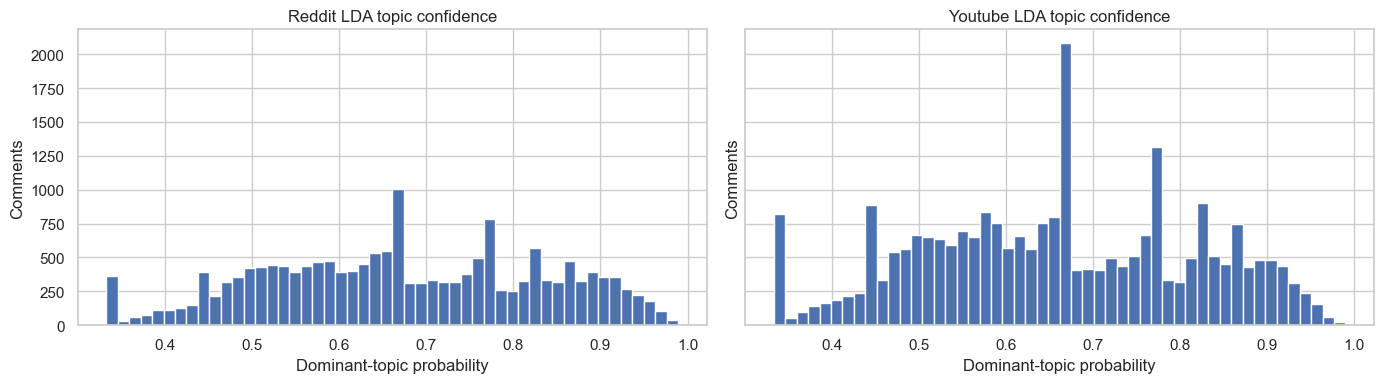

Dominant LDA topic-probability summary by platform:


,count,mean,std,25%,50%,75%,max
platform,,,,,,,
reddit,17162.0,0.674105,0.157481,0.551764,0.666509,0.803994,0.989089
youtube,26136.0,0.658375,0.157191,0.538513,0.662331,0.777751,0.990441


In [39]:
fig, axes = plt.subplots(1, len(PLATFORMS_FOR_TOPICS), figsize=(7 * len(PLATFORMS_FOR_TOPICS), 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, platform in zip(axes, PLATFORMS_FOR_TOPICS):
    sub = dominant_with_label[dominant_with_label["platform"] == platform]
    ax.hist(sub["topic_probability"], bins=50, edgecolor="white")
    ax.set_xlabel("Dominant-topic probability")
    ax.set_title(f"{platform.title()} LDA topic confidence")
    ax.set_ylabel("Comments")

plt.tight_layout()
plt.savefig(PLOTS / "topic_confidence_distribution_by_platform.png", dpi=160, bbox_inches="tight")
plt.show()

confidence_summary = (
    dominant_with_label.groupby("platform")["topic_probability"]
    .describe()[["count", "mean", "std", "25%", "50%", "75%", "max"]]
)
confidence_summary.to_csv(SENTIMENT_TOPICS / "topic_confidence_summary_by_platform.csv")
print("Dominant LDA topic-probability summary by platform:")
display(confidence_summary)


## 14 · LDA topic quality and stability across random seeds

This section checks whether the LDA topics are defensible enough to interpret in
the report. It does **not** prove that the topics are objectively true. Topic
modelling is exploratory: the checks below tell us how cautious we should be when
naming and comparing topics.

### 16.1 Per-topic quality table

The quality table has one row per platform-specific LDA topic.

- **`doc_count`**: how many comments were assigned to this topic as their dominant
  topic. Very small topics can be real, but they should be interpreted cautiously.
- **`top_terms`**: the words that most strongly define the topic. These are used
  for manual labelling together with representative comments.
- **`umass_coherence`**: a word co-occurrence score. For each topic, it asks whether
  the top words tend to appear in the same comments. Values are usually negative.
  Less negative / higher values are better. For example, `-2.1` is better than
  `-4.0`. Do not compare this as an absolute grade; use it mainly to compare topics
  within the same corpus/platform.
- **`mean_topic_probability`**: among comments assigned to that topic, the average
  LDA probability of the dominant topic. Higher values mean comments are more
  clearly assigned to that topic. Lower values mean comments sit between multiple
  topics, so the topic boundary is fuzzier.

A good topic is not simply the topic with the highest coherence. The best report
interpretation uses all four signals: sizeable `doc_count`, interpretable
`top_terms`, relatively better coherence, and a reasonable mean topic probability.

### 16.2 Stability across random seeds

LDA has random initialisation. If we refit the same model with different seeds,
we want broadly similar top words to reappear. The stability check compares the
sets of top-10 words across seed pairs using **Jaccard similarity**:

- `1.0` means the two runs found the same top words.
- `0.0` means there was no overlap.
- Higher `mean_jaccard` means the platform's topic solution is more stable.
- Low `min_jaccard` means at least one topic is unstable even if the average looks
  acceptable.

Rule of thumb for this notebook:

- **0.60+**: reasonably stable; topic labels are easier to defend.
- **0.40–0.59**: moderate stability; use labels, but acknowledge some fuzziness.
- **below 0.40**: weak stability; interpret as broad frames rather than precise
  clusters.

If a platform has weak stability, the correct response is not necessarily to throw
away the model. It means the report should avoid overclaiming fine-grained topic
boundaries and should focus on broader, repeated frames visible in the top words
and representative comments.


In [40]:
def lda_topic_quality_table(df_, result, platform, top_n=10):
    model = result["model"]
    W = result["doc_topic"]
    X = topic_vector_spaces[platform]["count_matrix"]
    vocab = topic_vector_spaces[platform]["count_vocab"]
    binary = (X > 0).astype(int)
    df_local = df_.reset_index(drop=True)
    dominant_ = W.argmax(axis=1)
    rows = []
    for tid in range(model.components_.shape[0]):
        top_idx = np.argsort(model.components_[tid])[::-1][:top_n]
        top_terms = vocab[top_idx].tolist()
        sub = binary[:, top_idx]
        co = (sub.T @ sub).toarray()
        df_doc = co.diagonal().astype(float)
        score, pairs = 0.0, 0
        for i in range(len(top_idx)):
            for j in range(i):
                score += float(np.log((co[i, j] + 1.0) / (df_doc[j] if df_doc[j] > 0 else 1.0)))
                pairs += 1
        members = df_local[dominant_ == tid]
        probs_on_dom = W[dominant_ == tid, tid]
        platform_topic = f"{platform}_topic_{tid}"
        rows.append({
            "platform": platform,
            "topic_id": int(tid),
            "platform_topic": platform_topic,
            "topic_label": label_lookup.get(platform_topic, manual_topic_label(platform, tid)),
            "doc_count": int(len(members)),
            "umass_coherence": score / pairs if pairs else float("nan"),
            "mean_topic_probability": float(probs_on_dom.mean()) if len(probs_on_dom) else float("nan"),
            "top_terms": ", ".join(top_terms),
        })
    return pd.DataFrame(rows)

quality_tables = []
for platform, result in lda_platform_results.items():
    quality_tables.append(lda_topic_quality_table(topic_corpus[platform], result, platform, top_n=10))

platform_topic_quality = pd.concat(quality_tables, ignore_index=True)
platform_topic_quality = platform_topic_quality.sort_values(["platform", "umass_coherence"], ascending=[True, False])
platform_topic_quality.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_quality.csv", index=False)
platform_topic_quality.to_csv(SENTIMENT_TOPICS / "topics_platform_quality.csv", index=False)
print("Per-topic LDA quality table by platform:")
display(platform_topic_quality)


# Plain-language interpretation helper for the quality table.
def _topic_probability_reading(value):
    if pd.isna(value):
        return "not available"
    if value >= 0.65:
        return "clear dominant-topic assignments"
    if value >= 0.50:
        return "moderately clear assignments"
    return "diffuse / mixed-topic assignments"

platform_topic_quality_interpreted = platform_topic_quality.copy()
platform_topic_quality_interpreted["coherence_rank_within_platform"] = (
    platform_topic_quality_interpreted.groupby("platform")["umass_coherence"]
    .rank(ascending=False, method="dense")
    .astype(int)
)
platform_topic_quality_interpreted["topic_probability_reading"] = (
    platform_topic_quality_interpreted["mean_topic_probability"].apply(_topic_probability_reading)
)

print("How to read the LDA topic quality table:")
display(platform_topic_quality_interpreted[[
    "platform", "topic_id", "topic_label", "doc_count",
    "coherence_rank_within_platform", "umass_coherence",
    "mean_topic_probability", "topic_probability_reading", "top_terms"
]])


Per-topic LDA quality table by platform:


,platform,topic_id,platform_topic,topic_label,doc_count,umass_coherence,mean_topic_probability,top_terms
2,reddit,2,reddit_topic_2,Iran-US geopolitical conflict and war risk,5694,-2.249900,0.693747,"iran, usa, war, country, israel, trump, world, iranian, military, china"
0,reddit,0,reddit_topic_0,Strait of Hormuz and oil-market disruption,4874,-2.541211,0.634123,"oil, strait, ship, open, china, week, hormuz, something, trump, day"
1,reddit,1,reddit_topic_1,"Trump, markets, and US economic reaction",6594,-3.247480,0.686698,"market, trump, price, money, american, stock, lol, enough, yeah, gas"
4,youtube,1,youtube_topic_1,"Iran-US conflict, Israel, and military escalation",10294,-2.305118,0.676181,"iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country"
3,youtube,0,youtube_topic_0,Global power politics and US-China rivalry,8384,-2.721679,0.614041,"world, china, trump, america, usa, country, american, state, gulf, tanker"
5,youtube,2,youtube_topic_2,"Oil, gas prices, and global energy supply",7458,-3.018013,0.683636,"oil, price, gas, year, fuel, india, usa, news, market, energy"


How to read the LDA topic quality table:


,platform,topic_id,topic_label,doc_count,coherence_rank_within_platform,umass_coherence,mean_topic_probability,topic_probability_reading,top_terms
2,reddit,2,Iran-US geopolitical conflict and war risk,5694,1,-2.249900,0.693747,clear dominant-topic assignments,"iran, usa, war, country, israel, trump, world, iranian, military, china"
0,reddit,0,Strait of Hormuz and oil-market disruption,4874,2,-2.541211,0.634123,moderately clear assignments,"oil, strait, ship, open, china, week, hormuz, something, trump, day"
1,reddit,1,"Trump, markets, and US economic reaction",6594,3,-3.247480,0.686698,clear dominant-topic assignments,"market, trump, price, money, american, stock, lol, enough, yeah, gas"
4,youtube,1,"Iran-US conflict, Israel, and military escalation",10294,1,-2.305118,0.676181,clear dominant-topic assignments,"iran, usa, trump, war, israel, strait, ship, iranian, hormuz, country"
3,youtube,0,Global power politics and US-China rivalry,8384,2,-2.721679,0.614041,moderately clear assignments,"world, china, trump, america, usa, country, american, state, gulf, tanker"
5,youtube,2,"Oil, gas prices, and global energy supply",7458,3,-3.018013,0.683636,clear dominant-topic assignments,"oil, price, gas, year, fuel, india, usa, news, market, energy"


In [41]:
# Stability check: refit each platform-specific LDA with multiple random seeds.
SEEDS = [0, 1, 2]


def lda_top_term_sets(model_, vocab_, n_top=10):
    return [set(vocab_[np.argsort(model_.components_[t])[::-1][:n_top]].tolist())
            for t in range(model_.components_.shape[0])]


def best_jaccard_match(sets_a, sets_b):
    used_b = set()
    rows = []
    for ia, sa in enumerate(sets_a):
        best_jacc, best_ib = -1.0, -1
        for ib, sb in enumerate(sets_b):
            if ib in used_b:
                continue
            union = sa | sb
            jacc = len(sa & sb) / len(union) if union else 0.0
            if jacc > best_jacc:
                best_jacc, best_ib = jacc, ib
        if best_ib >= 0:
            used_b.add(best_ib)
            rows.append({"a_topic": ia, "b_topic": best_ib, "jaccard": best_jacc})
    return pd.DataFrame(rows)

stability_rows = []
for platform in topic_corpus:
    if platform not in BEST_K_LDA_BY_PLATFORM:
        continue
    X_counts = topic_vector_spaces[platform]["count_matrix"]
    vocab = topic_vector_spaces[platform]["count_vocab"]
    k = BEST_K_LDA_BY_PLATFORM[platform]

    seed_models = []
    for seed in SEEDS:
        model = LatentDirichletAllocation(
            n_components=k, max_iter=50, learning_method="online",
            random_state=seed, n_jobs=1,
        )
        model.fit(X_counts)
        seed_models.append(model)
    seed_top_sets = [lda_top_term_sets(model, vocab, n_top=10) for model in seed_models]

    for (i, sa), (j, sb) in itertools.combinations(enumerate(seed_top_sets), 2):
        match_df = best_jaccard_match(sa, sb)
        stability_rows.append({
            "platform": platform,
            "seed_a": SEEDS[i],
            "seed_b": SEEDS[j],
            "mean_jaccard": round(float(match_df["jaccard"].mean()), 3),
            "min_jaccard": round(float(match_df["jaccard"].min()), 3),
        })

platform_stability_df = pd.DataFrame(stability_rows)
platform_stability_df.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_stability_seeds.csv", index=False)
platform_stability_df.to_csv(SENTIMENT_TOPICS / "topics_platform_stability_seeds.csv", index=False)
print("LDA top-term stability across seeds by platform:")
display(platform_stability_df)

platform_stability_mean = platform_stability_df.groupby("platform")["mean_jaccard"].mean().to_dict()
print("Mean LDA seed-stability Jaccard by platform:", {k: round(v, 3) for k, v in platform_stability_mean.items()})


# Plain-language interpretation helper for seed stability.
def _stability_reading(value):
    if pd.isna(value):
        return "not available"
    if value >= 0.60:
        return "reasonably stable"
    if value >= 0.40:
        return "moderately stable"
    return "weak / broad-frame interpretation only"

platform_stability_interpretation = (
    platform_stability_df.groupby("platform")
    .agg(
        mean_seed_jaccard=("mean_jaccard", "mean"),
        weakest_seed_pair_jaccard=("min_jaccard", "min"),
    )
    .reset_index()
)
platform_stability_interpretation["stability_reading"] = (
    platform_stability_interpretation["mean_seed_jaccard"].apply(_stability_reading)
)
platform_stability_interpretation.to_csv(SENTIMENT_TOPICS / "topics_lda_platform_stability_interpretation.csv", index=False)
print("Plain-language LDA seed-stability interpretation:")
display(platform_stability_interpretation.round(3))


LDA top-term stability across seeds by platform:


,platform,seed_a,seed_b,mean_jaccard,min_jaccard
0,reddit,0,1,0.453,0.111
1,reddit,0,2,0.389,0.250
2,reddit,1,2,0.212,0.053
3,youtube,0,1,0.632,0.538
4,youtube,0,2,0.138,0.053
5,youtube,1,2,0.545,0.429


Mean LDA seed-stability Jaccard by platform: {'reddit': 0.351, 'youtube': 0.438}
Plain-language LDA seed-stability interpretation:


,platform,mean_seed_jaccard,weakest_seed_pair_jaccard,stability_reading
0,reddit,0.351,0.053,weak / broad-frame interpretation only
1,youtube,0.438,0.053,moderately stable


## 15 · Findings and headline numbers for the report


In [42]:
# Compute everything the findings markdown wants to quote, in one place.
n_total = len(df)
n_reddit = int((df["platform"] == "reddit").sum())
n_youtube = int((df["platform"] == "youtube").sum())

headline_pct = (df.groupby("platform")["headline_sentiment_label"]
                  .value_counts(normalize=True).unstack(fill_value=0) * 100).round(1)
headline_score_means = df.groupby("platform")["headline_sentiment_score"].mean().round(3).to_dict()

vader_pct = (df.groupby("platform")["vader_label"]
               .value_counts(normalize=True).unstack(fill_value=0) * 100).round(1)
vader_compound_means = df.groupby("platform")["vader_compound"].mean().round(3).to_dict()

_vt_row = agreement_df.loc[agreement_df["pair"].str.contains("VADER  vs  Transformer")]
pair_agree_vader_tx = float(_vt_row["agreement_pct"].values[0]) if not _vt_row.empty else float("nan")
pair_kappa_vader_tx = float(_vt_row["cohen_kappa"].values[0]) if not _vt_row.empty else float("nan")

most_negative_by_platform = {}
for platform in PLATFORMS_FOR_TOPICS:
    sub = platform_topic_sentiment_summary[platform_topic_sentiment_summary["platform"] == platform]
    if not sub.empty:
        row = sub.sort_values("pct_negative", ascending=False).iloc[0]
        most_negative_by_platform[platform] = {
            "platform_topic": row["platform_topic"],
            "label": row["topic_label"],
            "pct_negative": float(row["pct_negative"]),
            "mean_headline_sentiment": float(row["mean_headline_sentiment"]),
            "sentiment_method": row.get("sentiment_method", HEADLINE_SENTIMENT_METHOD),
        }

cross_platform_topic_alignment_mean = (
    float(topic_platform_alignment["jaccard_top10"].mean())
    if "topic_platform_alignment" in globals() and not topic_platform_alignment.empty
    else float("nan")
)

all_three_methods_agree_pct = (
    float(all_three.mean() * 100)
    if "all_three" in globals() and len(all_three)
    else None
)

warnings_list = []
if (platform_topic_quality["mean_topic_probability"] < 0.35).any():
    warnings_list.append("Some platform-specific LDA topics have low mean dominant probability; interpret them as broad frames, not crisp clusters.")
for platform, mean_jacc in platform_stability_mean.items():
    if mean_jacc < 0.4:
        warnings_list.append(
            f"{platform.title()} LDA top-term stability across seeds is weak "
            f"(mean Jaccard {mean_jacc:.2f}). Treat topic boundaries cautiously."
        )
if pd.notna(cross_platform_topic_alignment_mean) and cross_platform_topic_alignment_mean < 0.3:
    warnings_list.append(
        f"Reddit and YouTube topics have weak top-term overlap on average "
        f"(mean Jaccard {cross_platform_topic_alignment_mean:.2f}); emphasise platform-specific framing rather than direct one-to-one equivalence."
    )
if HEADLINE_LABEL_COL == "tx_label" and transformer_label_coverage < 0.95:
    warnings_list.append(
        f"Transformer sentiment coverage is {transformer_label_coverage * 100:.1f}%; headline sentiment summaries use scored rows only."
    )

findings = {
    "generated_at_utc": datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
    "corpus": {
        "total_comments": int(n_total),
        "reddit_comments": n_reddit,
        "youtube_comments": n_youtube,
    },
    "sentiment_method": HEADLINE_SENTIMENT_METHOD,
    "sentiment_method_note": "Transformer is the headline scorer when available; VADER and Bing Liu are retained as baselines.",
    "transformer_scope": transformer_scope,
    "transformer_label_coverage": transformer_label_coverage,
    "headline_label_share_pct_by_platform": headline_pct.to_dict(),
    "headline_score_mean_by_platform": headline_score_means,
    "vader_label_share_pct_by_platform_baseline": vader_pct.to_dict(),
    "vader_compound_mean_by_platform_baseline": vader_compound_means,
    "agreement_summary": agreement_df.to_dict(orient="records"),
    "all_three_methods_agree_pct": all_three_methods_agree_pct,
    "vader_vs_transformer_agreement_pct": float(pair_agree_vader_tx),
    "vader_vs_transformer_cohen_kappa": float(pair_kappa_vader_tx),
    "topic_modelling": {
        "design": "Independent platform-specific LDA topic models, then Reddit/YouTube topics compared by top-term Jaccard overlap.",
        "headline_method": "LDA on raw count vectors (Week 6 course-aligned method)",
        "lda_chosen_k_by_platform": BEST_K_LDA_BY_PLATFORM,
        "nmf_optional_chosen_k_by_platform": BEST_K_NMF_BY_PLATFORM,
        "reddit_youtube_topic_alignment_mean_jaccard_top10": round(float(cross_platform_topic_alignment_mean), 3) if pd.notna(cross_platform_topic_alignment_mean) else None,
        "lda_seed_stability_mean_jaccard_by_platform": {k: round(float(v), 3) for k, v in platform_stability_mean.items()},
        "most_negative_topic_by_platform": most_negative_by_platform,
    },
    "warnings": warnings_list,
}

with open(SENTIMENT_TOPICS / "findings_summary.json", "w") as f:
    json.dump(findings, f, indent=2, default=str)

print("Findings summary (also written to findings_summary.json):\n")
print(json.dumps(findings, indent=2, default=str))


Findings summary (also written to findings_summary.json):

{
  "generated_at_utc": "2026-05-24T13:23:23+00:00",
  "corpus": {
    "total_comments": 43298,
    "reddit_comments": 17162,
    "youtube_comments": 26136
  },
  "sentiment_method": "Transformer (twitter-roberta)",
  "sentiment_method_note": "Transformer is the headline scorer when available; VADER and Bing Liu are retained as baselines.",
  "transformer_scope": "full_corpus",
  "transformer_label_coverage": 1.0,
  "headline_label_share_pct_by_platform": {
    "negative": {
      "reddit": 57.1,
      "youtube": 54.3
    },
    "neutral": {
      "reddit": 35.8,
      "youtube": 33.8
    },
    "positive": {
      "reddit": 7.1,
      "youtube": 11.9
    }
  },
  "headline_score_mean_by_platform": {
    "reddit": -0.406,
    "youtube": -0.344
  },
  "vader_label_share_pct_by_platform_baseline": {
    "negative": {
      "reddit": 40.8,
      "youtube": 38.9
    },
    "neutral": {
      "reddit": 24.8,
      "youtube": 29.8
  

## Generated artifacts

Relevant existing outputs from this notebook are:

- `data/processed/03_sentiment_topics/sentiment_comment_level.csv`
- `data/processed/03_sentiment_topics/sentiment_summary_by_platform.csv`
- `data/processed/03_sentiment_topics/sentiment_agreement_summary.csv`
- `data/processed/03_sentiment_topics/sentiment_daily_by_platform.csv`
- `data/processed/03_sentiment_topics/topics_lda_platform_labelled.csv`
- `data/processed/03_sentiment_topics/topics_lda_platform_dominant_per_comment_labelled.csv`
- `data/processed/03_sentiment_topics/topics_platform_dominant_per_comment_labelled.csv`
- `data/processed/03_sentiment_topics/topic_prevalence_platform_specific.csv`
- `data/processed/03_sentiment_topics/platform_topic_sentiment_summary.csv`
- `data/processed/03_sentiment_topics/topics_lda_platform_quality.csv`, `topics_platform_quality.csv`
- `data/processed/03_sentiment_topics/topics_lda_platform_stability_seeds.csv`, `topics_platform_stability_seeds.csv`
- `data/processed/03_sentiment_topics/topics_lda_reddit_youtube_alignment.csv`

## Report-ready findings

- Transformer sentiment is the headline sentiment method; VADER and Bing Liu remain transparent course-aligned baselines.
- Both platforms are strongly negative, but the platform difference is substantively modest and is interpreted together with effect sizes in notebook 08.
- The topic model should be read as broad crisis frames, not precise event labels. The report uses platform-specific LDA topic prevalence, topic sentiment, and seed stability rather than optional NMF outputs.
- The central text finding is that Hormuz discussion is framed mainly through geopolitics, oil supply, shipping/security, markets, and war risk. Explicit jet-fuel/aviation language is rare and is treated as a downstream implication rather than the main public vocabulary.
